# Input Configuration Evaluation: FHR-only vs FHR+UC

This notebook compares two signal input configurations (FHR-only vs FHR+UC) for 3-class CTG classification
using the same model architecture and grouped 10-fold cross-validation.

## 1. Imports

In [ ]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
from pathlib import Path
import wfdb
import json
import warnings
from typing import Dict, List, Tuple, Optional

from scipy.interpolate import interp1d

from sklearn.metrics import (
    confusion_matrix, f1_score, accuracy_score,
    balanced_accuracy_score, precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, MaxPooling1D, Dropout, GlobalAveragePooling1D,
    Dense, Reshape, Multiply, Add, Flatten, Concatenate,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
)
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import seaborn as sns

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

## 2. Configuration

In [ ]:
RAW_DATASET  = Path("../data/raw_dataset")
STEP2_LABELS = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS = Path("../ExpertAnnotations/step3_labels.csv")
OUTPUT_ROOT  = Path("outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

In [ ]:
RAW_SAMPLING_RATE    = 4
TARGET_SAMPLING_RATE = 1
DOWNSAMPLE_FACTOR    = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE
WINDOW_MINUTES       = 30
WINDOW_LENGTH        = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE
SAMPLING_RATE        = TARGET_SAMPLING_RATE
SEGMENT_MINUTES      = WINDOW_MINUTES
SEGMENT_LENGTH       = WINDOW_LENGTH

In [ ]:
NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

In [ ]:
CFG = dict(
    step_numbers            = [2, 3],
    mode_a_offsets          = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes         = SEGMENT_MINUTES,
    segment_length          = SEGMENT_LENGTH,
    max_nan_fraction        = 0.16,
    pad_short_records       = False,
    n_splits                = 10,
    cv_seed                 = 42,
    min_severe_records      = 10,
    max_cv_attempts         = 100,
    temporal_filters        = 32,
    separable_filters       = 32,
    separable_kernels       = [3, 7, 15],
    projection_filters      = 32,
    dropout_rate            = 0.40,
    use_clinical_features   = False,
    oversample_severe       = False,
    severe_boost            = 0.0,
    augment_train           = True,
    aug_time_warp           = True,
    aug_warp_sigma          = 0.10,
    aug_amplitude_scale     = True,
    aug_amp_sigma           = 0.10,
    aug_noise               = True,
    aug_noise_std           = 0.02,
    aug_signal_loss         = True,
    aug_gap_frac            = 0.05,
    aug_n_gaps              = 2,
    scratch_epochs          = 100,
    scratch_lr              = 1e-3,
    scratch_batch           = 16,
    scratch_patience        = 20,
    label_smoothing         = 0.05,
    use_class_weights       = True,
)

INPUT_COMPARISON_RUNS = [
    {
        'run_name': 'FHR-only',
        'include_uc': False,
        'n_signal_channels': 1,
        'output_subdir': 'fhr_only',
    },
    {
        'run_name': 'FHR+UC',
        'include_uc': True,
        'n_signal_channels': 2,
        'output_subdir': 'fhr_and_uc',
    },
]

windows_per_step = {s: len(v) for s, v in CFG['controlled_step_offsets'].items()}
CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))

print("Configuration loaded.")
print(f"  Segment length: {CFG['segment_length']} samples ({CFG['segment_minutes']} min)")
print(f"  CV folds: {CFG['n_splits']} | Controlled windows/step: {CONTROLLED_WINDOWS_PER_STEP}")
print(f"  Experiments: {[r['run_name'] for r in INPUT_COMPARISON_RUNS]}")

## 3. Multimodal Data Loading

In [ ]:
def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:
    step_labels = {}
    for step_num, path in step_paths.items():
        df = pd.read_csv(path)
        total = len(df)
        df = df[df['Majority_Vote_Label'] != -1].copy()
        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)
        df['rec_id'] = df['rec_id'].astype(str)
        excluded = total - len(df)
        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")
        for cls_id, name in enumerate(CLASS_NAMES):
            n = int((df['class_id'] == cls_id).sum())
            print(f"  Class {cls_id} ({name}): {n}")
        step_labels[step_num] = df
    return step_labels

In [ ]:
def trim_aligned_recording(fhr_signal: list, uc_signal: list) -> Tuple[list, list]:
    last_nonzero = -1
    for i in range(len(fhr_signal) - 1, -1, -1):
        if fhr_signal[i] != 0:
            last_nonzero = i
            break
    if last_nonzero < 0:
        return [], []
    return fhr_signal[:last_nonzero + 1], uc_signal[:last_nonzero + 1]

In [ ]:
def clean_aligned_fhr_uc(
    fhr_array,
    uc_array,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray]:
    fhr = pd.Series(np.array(fhr_array, dtype=float))
    fhr.replace(0, np.nan, inplace=True)
    na = fhr.isnull()
    gap_groups = na.ne(na.shift()).cumsum()
    gap_sizes = fhr.groupby(gap_groups.values).transform('size')
    keep_mask = ~(gap_sizes.ge(fs * 15 + 1) & na)
    fhr = fhr[keep_mask].reset_index(drop=True)
    uc = pd.Series(np.array(uc_array, dtype=float))[keep_mask].reset_index(drop=True)

    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan
    fhr = fhr.interpolate(method='linear')
    diff = fhr - fhr.shift()
    fhr[(diff > 25) | (diff < -25)] = np.nan
    fhr = fhr.interpolate(method='linear').ffill().bfill()

    uc_clean = pd.Series(np.array(uc, dtype=float)).ffill().bfill().fillna(0.0)

    return fhr.values, uc_clean.values

In [ ]:
def load_raw_signals_multimodal(dataset_path: Path) -> Dict[str, dict]:
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files in {dataset_path}")
    data = {}
    for rid in sorted(records):
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            p_signal = rec.p_signal
            if p_signal.shape[1] < 2:
                print(f"  Skipping {rid}: fewer than 2 channels")
                continue
            fhr_raw = p_signal[:, 0].tolist()
            uc_raw  = p_signal[:, 1].tolist()
            fhr_trimmed, uc_trimmed = trim_aligned_recording(fhr_raw, uc_raw)
            if not fhr_trimmed:
                print(f"  Skipping {rid}: no non-zero FHR samples")
                continue
            fhr_clean, uc_clean = clean_aligned_fhr_uc(fhr_trimmed, uc_trimmed, fs=RAW_SAMPLING_RATE)
            min_len = min(len(fhr_clean), len(uc_clean))
            fhr_clean = fhr_clean[:min_len]
            uc_clean  = uc_clean[:min_len]
            fhr_ds = fhr_clean[::DOWNSAMPLE_FACTOR].astype(np.float32)
            uc_ds  = uc_clean[::DOWNSAMPLE_FACTOR].astype(np.float32)
            data[rid] = {'FHR': fhr_ds, 'UC': uc_ds, 'length': len(fhr_ds)}
        except Exception as e:
            print(f"  Skipping {rid}: {e}")
    print(f"Loaded {len(data)} FHR+UC signals")
    return data

In [ ]:
def _window_bounds_from_end(
    sig_len: int,
    offsets_from_end_min: Tuple[int, int],
    fs: int = 4,
) -> Optional[Tuple[int, int]]:
    start_from_end_min, end_from_end_min = offsets_from_end_min
    if start_from_end_min <= end_from_end_min:
        raise ValueError(f"Expected start offset > end offset, got {offsets_from_end_min}")
    start_from_end = start_from_end_min * 60 * fs
    end_from_end = end_from_end_min * 60 * fs
    if sig_len < start_from_end:
        return None
    start_idx = sig_len - start_from_end
    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len
    if end_idx <= start_idx:
        return None
    return int(start_idx), int(end_idx)

In [ ]:
def _get_controlled_window_bounds(
    sig_len: int,
    step_num: int,
    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],
    fs: int = 4,
) -> Optional[List[Tuple]]:
    if step_num not in controlled_step_offsets:
        raise KeyError(f"Missing controlled offsets for step {step_num}")
    bounds = []
    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):
        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)
        if cur_bounds is None:
            return None
        start_idx, end_idx = cur_bounds
        bounds.append((window_index, offsets, start_idx, end_idx))
    return bounds

In [ ]:
def create_step_windows_multimodal(
    signal_data: Dict[str, dict],
    step_label_dfs: Dict[int, pd.DataFrame],
    record_ids: List[str],
    window_length: int = 7200,
    step_numbers: Optional[List[int]] = None,
    step_offsets: Optional[Dict[int, Tuple[int, int]]] = None,
    controlled_step_offsets: Optional[Dict[int, List[Tuple[int, int]]]] = None,
    max_nan_fraction: float = 0.16,
    pad_short_records: bool = False,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    if step_numbers is None:
        step_numbers = [2, 3]
    if step_offsets is None:
        step_offsets = {2: (60, 30), 3: (30, 0)}
    if controlled_step_offsets is None:
        controlled_step_offsets = {s: [step_offsets[s]] for s in step_numbers}

    X_fhr_list, X_uc_list, y_list, group_list, meta_list = [], [], [], [], []
    accepted = 0
    skipped_short = 0
    skipped_nan = 0

    for rid in record_ids:
        if rid not in signal_data:
            continue
        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)
        uc  = np.array(signal_data[rid]['UC'], dtype=np.float64)
        sig_len = len(fhr)

        for step_num in step_numbers:
            step_df = step_label_dfs.get(step_num)
            if step_df is None:
                continue
            row = step_df[step_df['rec_id'] == rid]
            if row.empty:
                continue

            controlled_bounds = _get_controlled_window_bounds(
                sig_len, step_num, controlled_step_offsets, fs=fs
            )
            if controlled_bounds is None:
                skipped_short += 1
                continue

            label = int(row['class_id'].iloc[0])
            step_windows_fhr = []
            step_windows_uc = []
            failed = False

            for window_index, offsets, start_idx, end_idx in controlled_bounds:
                fhr_win = fhr[start_idx:end_idx]
                uc_win  = uc[start_idx:end_idx]
                if len(fhr_win) < window_length:
                    if pad_short_records:
                        pad_len = window_length - len(fhr_win)
                        fhr_win = np.pad(fhr_win, (pad_len, 0), mode='edge')
                        uc_win  = np.pad(uc_win, (pad_len, 0), mode='edge')
                    else:
                        failed = True
                        skipped_short += 1
                        break
                missing_frac = float(np.mean(np.isnan(fhr_win) | (fhr_win == 0)))
                if missing_frac > max_nan_fraction:
                    failed = True
                    skipped_nan += 1
                    break
                if np.any(np.isnan(fhr_win)):
                    fhr_win = pd.Series(fhr_win).interpolate(method='linear').ffill().bfill().values
                if np.any(np.isnan(uc_win)):
                    uc_win = pd.Series(uc_win).ffill().bfill().fillna(0.0).values
                step_windows_fhr.append(fhr_win[:window_length].astype(np.float32))
                step_windows_uc.append(uc_win[:window_length].astype(np.float32))
                meta_list.append({
                    'rec_id': rid, 'step': step_num,
                    'window_index': window_index,
                    'offset_start_min': int(offsets[0]),
                    'offset_end_min': int(offsets[1]),
                    'label': label,
                    'missing_frac_fhr': missing_frac,
                })

            if failed:
                meta_list = meta_list[:-len(step_windows_fhr)]
                continue

            accepted += 1
            for fhr_win, uc_win in zip(step_windows_fhr, step_windows_uc):
                X_fhr_list.append(fhr_win)
                X_uc_list.append(uc_win)
                y_list.append(label)
                group_list.append(rid)

    n = len(X_fhr_list)
    X_fhr = np.array(X_fhr_list, dtype=np.float32)[:, :, np.newaxis] if n > 0 else np.empty((0, window_length, 1))
    X_uc  = np.array(X_uc_list, dtype=np.float32)[:, :, np.newaxis] if n > 0 else np.empty((0, window_length, 1))
    y     = np.array(y_list, dtype=np.int32)
    groups = np.array(group_list)
    metadata = pd.DataFrame(meta_list)

    print(f"Multimodal window extraction: {n} windows from {len(set(group_list))} records")
    print(f"  Accepted: {accepted} | Skipped short: {skipped_short} | Skipped NaN: {skipped_nan}")
    for cls_id, name in enumerate(CLASS_NAMES):
        print(f"  Class {cls_id} ({name}): {int(np.sum(y == cls_id))} windows")
    return X_fhr, X_uc, y, groups, metadata

In [ ]:
STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}
step_label_dfs = load_step_labels(STEP_LABEL_PATHS)
signal_data = load_raw_signals_multimodal(RAW_DATASET)

labelled_rec_ids = set()
for df in step_label_dfs.values():
    labelled_rec_ids.update(df['rec_id'].tolist())

valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))
print(f"Records with Step 2/3 label and FHR+UC signal: {len(valid_rec_ids)}")

In [ ]:
print("Extracting Step 2 + Step 3 controlled 30-minute windows (FHR + UC)...")
X_fhr_all, X_uc_all, y_all, groups_all, meta_all = create_step_windows_multimodal(
    signal_data=signal_data,
    step_label_dfs=step_label_dfs,
    record_ids=valid_rec_ids,
    window_length=CFG['segment_length'],
    step_numbers=CFG['step_numbers'],
    step_offsets=CFG['mode_a_offsets'],
    controlled_step_offsets=CFG['controlled_step_offsets'],
    max_nan_fraction=CFG['max_nan_fraction'],
    pad_short_records=CFG['pad_short_records'],
    fs=SAMPLING_RATE,
)
print(f"FHR shape: {X_fhr_all.shape} | UC shape: {X_uc_all.shape}")

## 4. Signal Tensor Builder

In [ ]:
def build_signal_tensor(
    X_fhr: np.ndarray,
    X_uc: np.ndarray,
    include_uc: bool,
) -> np.ndarray:
    if include_uc:
        return np.concatenate([X_fhr, X_uc], axis=-1).astype(np.float32)
    return X_fhr.astype(np.float32)

## 5. Normalization and Augmentation

In [ ]:
def compute_norm_stats_multichannel(X_train: np.ndarray) -> dict:
    n_channels = X_train.shape[-1]
    stats = {}
    for c in range(n_channels):
        channel_vals = X_train[:, :, c].ravel()
        mean = float(np.mean(channel_vals))
        std  = float(np.std(channel_vals))
        if std < 1e-8:
            std = 1.0
        stats[c] = {'mean': mean, 'std': std}
    return stats

In [ ]:
def apply_norm_multichannel(X: np.ndarray, stats: dict) -> np.ndarray:
    X_norm = X.astype(np.float32).copy()
    for c, channel_stats in stats.items():
        X_norm[:, :, c] -= channel_stats['mean']
        X_norm[:, :, c] /= channel_stats['std']
    return X_norm

In [ ]:
def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    N, T, C = X.shape
    X_warped = np.empty_like(X)
    orig_steps = np.arange(T)
    n_knots = 4
    knot_pos = np.linspace(0, T - 1, n_knots + 2)
    for i in range(N):
        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)
        warp_factors[0] = 1.0
        warp_factors[-1] = 1.0
        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])
        warped_knots = np.concatenate([[0], warped_knots])
        warped_knots = warped_knots / warped_knots[-1] * (T - 1)
        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')
        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)
        for c in range(C):
            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')
            X_warped[i, :, c] = interp_sig(warped_steps)
    return X_warped.astype(np.float32)

In [ ]:
def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    scales = np.random.normal(1.0, sigma, size=(X.shape[0], 1, 1)).astype(np.float32)
    return X * scales

In [ ]:
def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:
    return X + np.random.normal(0, noise_std, X.shape).astype(np.float32)

In [ ]:
def signal_loss_simulation(X: np.ndarray, max_gap_frac: float = 0.05, n_gaps: int = 2) -> np.ndarray:
    N, T, C = X.shape
    X_aug = X.copy()
    max_gap = max(1, int(T * max_gap_frac))
    for i in range(N):
        for _ in range(n_gaps):
            gap_len = np.random.randint(1, max_gap + 1)
            start = np.random.randint(0, T - gap_len)
            end = start + gap_len
            for c in range(C):
                left_val = X_aug[i, max(start - 1, 0), c]
                right_val = X_aug[i, min(end, T - 1), c]
                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)
    return X_aug.astype(np.float32)

In [ ]:
def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:
    X_aug = X.copy()
    if cfg.get('aug_time_warp', True):
        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))
    if cfg.get('aug_amplitude_scale', True):
        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))
    if cfg.get('aug_noise', True):
        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))
    if cfg.get('aug_signal_loss', True):
        X_aug = signal_loss_simulation(
            X_aug,
            max_gap_frac=cfg.get('aug_gap_frac', 0.05),
            n_gaps=cfg.get('aug_n_gaps', 2),
        )
    return X_aug

## 6. Multimodal Model Architecture

Hybrid Multi-Scale CNN that accepts a configurable number of input channels to accommodate both FHR-only
and FHR+UC experiments.

In [ ]:
def _se_block_1d(x, filters: int, reduction: int = 8):
    se = GlobalAveragePooling1D()(x)
    se = Dense(max(1, filters // reduction), activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, filters))(se)
    return Multiply()([x, se])

In [ ]:
def build_model_multimodal(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = NUM_CLASSES,
    n_signal_channels: int = 1,
    temporal_filters: int = 32,
    separable_filters: int = 32,
    separable_kernels: Optional[List[int]] = None,
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
) -> Model:
    if separable_kernels is None:
        separable_kernels = [3, 7, 15]

    signal_input = Input(shape=(input_length, n_signal_channels), name="signal_input")

    x = Conv1D(temporal_filters, 7, padding='same', use_bias=False, name='temporal_conv')(signal_input)
    x = BatchNormalization(name='temporal_bn')(x)
    x = Activation('relu', name='temporal_relu')(x)
    x = MaxPooling1D(4, name='temporal_pool')(x)
    x = Dropout(dropout_rate * 0.5, name='temporal_drop')(x)

    branches = []
    for k in separable_kernels:
        b = SeparableConv1D(separable_filters, k, padding='same', use_bias=False)(x)
        b = BatchNormalization()(b)
        b = Activation('relu')(b)
        b = _se_block_1d(b, separable_filters)
        branches.append(b)

    if len(branches) > 1:
        x_merged = Add()(branches) if all(b.shape == branches[0].shape for b in branches) else Concatenate()(branches)
        x_merged = Conv1D(projection_filters, 1, padding='same', use_bias=False, name='proj')(x_merged)
        x_merged = BatchNormalization(name='proj_bn')(x_merged)
        x_merged = Activation('relu', name='proj_relu')(x_merged)
    else:
        x_merged = branches[0]

    residual = Conv1D(projection_filters, 1, padding='same', use_bias=False, name='res_skip')(x)
    x_out = Add(name='residual_add')([x_merged, residual])
    x_out = Dropout(dropout_rate, name='final_drop')(x_out)
    x_out = GlobalAveragePooling1D(name='gap')(x_out)

    outputs = Dense(num_classes, activation='softmax', name='output')(x_out)
    model_name = f"MultiScale-CNN-{n_signal_channels}ch"
    return Model(signal_input, outputs, name=model_name)

## 7. Training Functions

In [ ]:
def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta

In [ ]:
def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    meta = _ensure_step_keys(metadata)
    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one label")
    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)

In [ ]:
def resolve_min_severe_threshold(
    metadata: pd.DataFrame,
    n_splits: int,
    requested_min: int = 10,
    severe_class: int = 2,
) -> Tuple[int, int, int]:
    step_targets = build_step_target_table(metadata.reset_index(drop=True))
    step_y = step_targets['label'].to_numpy(dtype=int)
    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0
    effective_min = requested_min
    if effective_min > min_possible:
        effective_min = max(min_possible - 1, 1) if total_severe > 0 else 0
        print(f"  WARNING: Requested >= {requested_min} Severe step-units/fold is infeasible; using {effective_min}.")
    return effective_min, total_severe, min_possible

In [ ]:
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return {int(c): float(w) for c, w in zip(classes, weights)}

In [ ]:
class RecordStepBalancedAccuracy(Callback):
    def __init__(self, X_val, val_metadata, batch_size=32):
        super().__init__()
        self.X_val = X_val
        self.val_metadata = _ensure_step_keys(val_metadata.reset_index(drop=True))
        self.batch_size = batch_size

    def _aggregate(self, y_proba):
        step_y_true, step_y_pred = [], []
        for step_key in self.val_metadata['step_key'].unique():
            mask = self.val_metadata['step_key'] == step_key
            mean_proba = y_proba[mask].mean(axis=0)
            step_y_true.append(int(self.val_metadata.loc[mask, 'label'].iloc[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))
        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        del epoch
        logs = logs or {}
        y_proba = self.model.predict(self.X_val, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")

In [ ]:
def get_callbacks(patience, monitor, monitor_mode, save_path=None) -> list:
    callbacks = [
        EarlyStopping(
            monitor=monitor, mode=monitor_mode,
            patience=patience, restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor, mode=monitor_mode,
            factor=0.5, patience=max(patience // 2, 3),
            min_lr=1e-6, verbose=1,
        ),
    ]
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path, monitor=monitor, mode=monitor_mode,
            save_best_only=True, save_weights_only=True, verbose=0,
        ))
    return callbacks

In [ ]:
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 10,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], int]:
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)
    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    effective_min, total_severe, min_possible = resolve_min_severe_threshold(
        meta, n_splits=n_splits, requested_min=min_severe_records, severe_class=severe_class,
    )
    print(f"  Total Severe step-units: {total_severe}, {n_splits} folds -> max ~{min_possible}/fold")

    best_folds = None
    best_min_severe = -1

    for attempt in range(max_attempts):
        seed = cv_seed + attempt
        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids   = set(step_targets.iloc[val_step_idx]['rec_id'])
            n_severe = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_severe)
            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask   = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))
            if n_severe < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds

        if all_ok:
            print(f"  Valid split at attempt {attempt + 1}: Severe per fold: {fold_severe_counts}")
            return candidate_folds, effective_min

    print(f"  WARNING: Could not meet >= {effective_min} Severe/fold. Best: {best_min_severe}")
    return best_folds, effective_min

In [ ]:
def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)
    step_counts = {
        cls_id: int(np.sum(step_targets['label'].to_numpy(dtype=int) == cls_id))
        for cls_id in range(NUM_CLASSES)
    }
    window_counts = {
        cls_id: int(np.sum(val_meta['label'].to_numpy(dtype=int) == cls_id))
        for cls_id in range(NUM_CLASSES)
    }
    n_severe = step_counts.get(severe_class, 0)
    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_severe,
        is_reliable=(n_severe >= min_severe_records),
    )
    return stats['is_reliable'], stats

In [ ]:
def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true, step_y_pred = [], []
    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))
    return unique_step_keys, np.array(step_y_true, dtype=int), np.array(step_y_pred, dtype=int)

In [ ]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    labels = list(range(NUM_CLASSES))
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    metrics = {'accuracy': acc, 'balanced_accuracy': bal_acc, 'macro_f1': macro_f1, 'confusion_matrix': cm}
    for i, name in enumerate(CLASS_NAMES):
        metrics[f'precision_{name}'] = float(precision[i])
        metrics[f'recall_{name}'] = float(recall[i])
        metrics[f'f1_{name}'] = float(f1[i])
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0
    return metrics

In [ ]:
def print_metrics(metrics: dict, prefix: str = "") -> None:
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")

## 8. Input-Variant Cross-Validation

The same grouped folds are reused for both experiments to ensure a fair comparison with no data leakage.

In [ ]:
def run_grouped_cv_input_variant(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    run_name: str,
    n_signal_channels: int,
    output_dir: Path,
    shared_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None,
    effective_min_severe: int = 10,
    manual_class_weights: Optional[dict] = None,
) -> List[dict]:
    output_dir.mkdir(parents=True, exist_ok=True)
    metadata = _ensure_step_keys(metadata.reset_index(drop=True))
    n_splits = cfg['n_splits']

    if shared_folds is None:
        shared_folds, effective_min_severe = stratified_record_kfold_with_constraint(
            metadata,
            n_splits=n_splits,
            min_severe_records=cfg.get('min_severe_records', 10),
            max_attempts=cfg.get('max_cv_attempts', 100),
            cv_seed=cfg['cv_seed'],
        )

    fold_results = []
    all_step_y_true, all_step_y_pred = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(shared_folds):
        print(f"\n[{run_name}] Fold {fold_idx + 1} / {n_splits}")

        is_reliable, val_stats = analyze_validation_set(
            metadata, val_idx, min_severe_records=effective_min_severe,
        )

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        assert len(set(g_train) & set(g_val)) == 0, "DATA LEAKAGE"
        print(f"  Train: {len(X_train)} windows | Val: {len(X_val)} windows")

        norm_stats = compute_norm_stats_multichannel(X_train)
        X_train_n  = apply_norm_multichannel(X_train, norm_stats)
        X_val_n    = apply_norm_multichannel(X_val, norm_stats)

        tf.keras.backend.clear_session()
        model = build_model_multimodal(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            n_signal_channels=n_signal_channels,
            temporal_filters=cfg.get('temporal_filters', 32),
            separable_filters=cfg.get('separable_filters', 32),
            separable_kernels=cfg.get('separable_kernels', [3, 7, 15]),
            projection_filters=cfg.get('projection_filters', 32),
            dropout_rate=cfg.get('dropout_rate', 0.40),
        )

        if manual_class_weights is not None:
            cw = {int(k): float(v) for k, v in manual_class_weights.items()}
        else:
            cw = compute_class_weights_from_y(y_train)

        label_smoothing = float(cfg.get('label_smoothing', 0.0))
        model.compile(
            optimizer=Adam(learning_rate=cfg['scratch_lr']),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
            metrics=['accuracy'],
        )

        X_train_aug = augment_signal(X_train_n, cfg) if cfg.get('augment_train', False) else X_train_n.copy()
        y_train_cat = to_categorical(y_train, NUM_CLASSES)
        y_val_cat   = to_categorical(y_val, NUM_CLASSES)

        save_path = str(output_dir / f"fold{fold_idx + 1}_best.weights.h5")
        monitor_callback = RecordStepBalancedAccuracy(
            X_val=X_val_n, val_metadata=meta_val, batch_size=32,
        )
        model.fit(
            X_train_aug, y_train_cat,
            validation_data=(X_val_n, y_val_cat),
            epochs=cfg['scratch_epochs'],
            batch_size=cfg['scratch_batch'],
            class_weight=cw,
            callbacks=[monitor_callback] + get_callbacks(
                patience=cfg['scratch_patience'],
                monitor='val_record_step_balanced_accuracy',
                monitor_mode='max',
                save_path=save_path,
            ),
            verbose=1,
        )

        y_proba = model.predict(X_val_n, batch_size=32, verbose=0)
        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        fold_results.append(metrics)
        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        print_metrics(metrics, prefix=f"[{run_name}] Fold {fold_idx + 1} ")

    print(f"\n[{run_name}] Summary:")
    for key in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        vals = [r[key] for r in fold_results]
        print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    _plot_cm(overall_cm, title=f"{run_name} Overall CM", save_path=output_dir / "overall_cm.png")
    _plot_fold_bar(fold_results, run_name, save_path=output_dir / "fold_summary.png")

    return fold_results

## 9. Visualisation

In [ ]:
def _plot_cm(cm: np.ndarray, title: str = "Confusion Matrix", save_path=None) -> None:
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(str(save_path), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def _plot_fold_bar(fold_results: List[dict], run_name: str, save_path=None) -> None:
    f1s = [r['macro_f1'] for r in fold_results]
    folds = list(range(1, len(f1s) + 1))
    _, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(np.mean(f1s), color='red', linestyle='--', label=f"Mean = {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}")
    ax.set_title(f"{run_name} - Per-Fold Macro F1", fontsize=14)
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(str(save_path), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def build_experiment_summary(
    run_cfg: dict,
    fold_results: List[dict],
    global_cfg: dict,
) -> dict:
    return {
        'run_name': run_cfg['run_name'],
        'include_uc': run_cfg['include_uc'],
        'n_signal_channels': run_cfg['n_signal_channels'],
        'n_folds': len(fold_results),
        'n_reliable_folds': sum(1 for r in fold_results if r.get('is_reliable', True)),
        'window_length': global_cfg['segment_length'],
        'mean_macro_f1': float(np.mean([r['macro_f1'] for r in fold_results])),
        'std_macro_f1': float(np.std([r['macro_f1'] for r in fold_results])),
        'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in fold_results])),
        'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in fold_results])),
        'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in fold_results])),
        'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in fold_results])),
        'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in fold_results])),
        'per_fold': [{k: v for k, v in r.items() if k != 'confusion_matrix'} for r in fold_results],
    }

## 10. Run Experiments

Runs both FHR-only and FHR+UC experiments sharing the same folds for a directly comparable evaluation.

In [ ]:
print("Pre-computing shared cross-validation folds...")
shared_folds, effective_min_severe = stratified_record_kfold_with_constraint(
    meta_all,
    n_splits=CFG['n_splits'],
    min_severe_records=CFG['min_severe_records'],
    max_attempts=CFG['max_cv_attempts'],
    cv_seed=CFG['cv_seed'],
)
print(f"Shared folds computed: {len(shared_folds)} folds, effective min Severe = {effective_min_severe}")

In [ ]:
MANUAL_CLASS_WEIGHTS = {0: 0.9, 1: 1.2, 2: 2.5}
ALL_EXPERIMENT_RESULTS = {}

for run_cfg in INPUT_COMPARISON_RUNS:
    run_name       = run_cfg['run_name']
    include_uc     = run_cfg['include_uc']
    n_channels     = run_cfg['n_signal_channels']
    output_subdir  = OUTPUT_ROOT / run_cfg['output_subdir']

    print("\n" + "=" * 70)
    print(f"EXPERIMENT: {run_name}  (channels={n_channels})")
    print("=" * 70)

    X_run = build_signal_tensor(X_fhr_all, X_uc_all, include_uc=include_uc)
    print(f"Input tensor shape: {X_run.shape}")

    fold_results = run_grouped_cv_input_variant(
        X=X_run,
        y=y_all,
        groups=groups_all,
        metadata=meta_all,
        cfg=CFG,
        run_name=run_name,
        n_signal_channels=n_channels,
        output_dir=output_subdir,
        shared_folds=shared_folds,
        effective_min_severe=effective_min_severe,
        manual_class_weights=MANUAL_CLASS_WEIGHTS,
    )

    summary = build_experiment_summary(run_cfg, fold_results, CFG)
    ALL_EXPERIMENT_RESULTS[run_name] = {'summary': summary, 'fold_results': fold_results}

    with open(output_subdir / f"{run_cfg['output_subdir']}_results.json", 'w') as f:
        json.dump(summary, f, indent=2, default=str)
    print(f"\nResults for '{run_name}' saved to {output_subdir}")

print("\nAll input evaluation experiments complete.")

## 11. Results Comparison

In [ ]:
def _fmt(vals):
    return f"{np.mean(vals):.4f} +/- {np.std(vals):.4f}"

print("=" * 70)
print("INPUT ABLATION STUDY - FINAL COMPARISON")
print("=" * 70)
print(f"{'Metric':<25} {'FHR-only':>20} {'FHR+UC':>20}")
print("-" * 70)

metrics_to_compare = [
    ('Macro F1', 'macro_f1'),
    ('Balanced Accuracy', 'balanced_accuracy'),
    ('Accuracy', 'accuracy'),
    ('Recall - Normal', 'recall_Normal'),
    ('Recall - Mild', 'recall_Mild'),
    ('Recall - Severe', 'recall_Severe'),
]

for label, key in metrics_to_compare:
    row = f"  {label:<23}"
    for run_name in ['FHR-only', 'FHR+UC']:
        if run_name in ALL_EXPERIMENT_RESULTS:
            vals = [r[key] for r in ALL_EXPERIMENT_RESULTS[run_name]['fold_results']]
            row += f" {_fmt(vals):>20}"
        else:
            row += f" {'N/A':>20}"
    print(row)

print("="*70)
print("Reliable folds per experiment:")
for run_name in ['FHR-only', 'FHR+UC']:
    if run_name in ALL_EXPERIMENT_RESULTS:
        n_rel = ALL_EXPERIMENT_RESULTS[run_name]['summary']['n_reliable_folds']
        print(f"  {run_name}: {n_rel} / {CFG['n_splits']}")

In [ ]:
run_names = list(ALL_EXPERIMENT_RESULTS.keys())
if len(run_names) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    metric_keys = [('Macro F1', 'macro_f1'), ('Balanced Accuracy', 'balanced_accuracy'), ('Recall - Severe', 'recall_Severe')]
    colors = ['steelblue', 'darkorange']

    for ax, (metric_label, metric_key) in zip(axes, metric_keys):
        for rn, color in zip(run_names, colors):
            if rn not in ALL_EXPERIMENT_RESULTS:
                continue
            vals = [r[metric_key] for r in ALL_EXPERIMENT_RESULTS[rn]['fold_results']]
            folds = list(range(1, len(vals) + 1))
            ax.plot(folds, vals, marker='o', label=rn, color=color, alpha=0.8)
            ax.axhline(np.mean(vals), linestyle='--', color=color, alpha=0.5)

        ax.set_title(metric_label, fontsize=13)
        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_xticks(list(range(1, CFG['n_splits'] + 1)))
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

    plt.suptitle('FHR-only vs FHR+UC Input Ablation', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_ROOT / "input_ablation_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
comparison_rows = []
for run_name, data in ALL_EXPERIMENT_RESULTS.items():
    s = data['summary']
    comparison_rows.append({
        'Input Configuration': run_name,
        'N Channels': s['n_signal_channels'],
        'Macro F1': f"{s['mean_macro_f1']:.4f} +/- {s['std_macro_f1']:.4f}",
        'Balanced Accuracy': f"{s['mean_balanced_acc']:.4f} +/- {s['std_balanced_acc']:.4f}",
        'Recall Normal': f"{s['mean_recall_Normal']:.4f}",
        'Recall Mild': f"{s['mean_recall_Mild']:.4f}",
        'Recall Severe': f"{s['mean_recall_Severe']:.4f}",
        'Reliable Folds': f"{s['n_reliable_folds']}/{s['n_folds']}",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUT_ROOT / "input_ablation_summary.csv", index=False)
print("Input ablation summary saved.")
print(comparison_df.to_string(index=False))

# CTU-UHB Step 2+3 Multiclass Short Experiment Plan


Minimal refactor of the CTU-UHB multiclass pipeline for a focused dissertation-ready experiment.


## Goal

Improve **step-level / record-step 3-class performance**, especially **Mild recall**, while keeping grouped cross-validation by `rec_id` and the existing preprocessing logic.


## Minimal changes in this version

- Drop **Step 1** entirely

- Train and evaluate on **Step 2 + Step 3** 30-minute windows only, using **3 controlled windows per step**

- Increase the window-quality threshold to **`max_nan_fraction = 0.16`**

- Keep the standard **3-class softmax** CNN as the primary model

- Add a compact **engineered-feature branch** alongside the raw-signal CNN branch

- Standardize engineered features using **training-fold statistics only**

- Keep **grouped CV by `rec_id`** but evaluate at the **record-step level** rather than collapsing back to one label per record


## 1. Imports

In [173]:
# Disable oneDNN/MKL ops BEFORE importing TF 
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Core
import numpy as np
import pandas as pd
from pathlib import Path
import wfdb
import json
import warnings
from typing import Dict, List, Tuple

# Signal processing
from scipy.interpolate import interp1d
from scipy.signal import welch

# Sklearn
from sklearn.metrics import (
    confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
 )
from sklearn.utils.class_weight import compute_class_weight

# Try to import StratifiedGroupKFold (sklearn >= 1.0)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available - will use group-aware stratified splitting.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False
    print("WARNING: StratifiedGroupKFold not available (sklearn < 1.0).")
    print("         Falling back to GroupKFold - class balance across folds not guaranteed.")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, Dropout, GlobalAveragePooling1D, Dense,
    Concatenate, Reshape, Multiply, Add,
 )
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
 )
from tensorflow.keras.utils import to_categorical

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

StratifiedGroupKFold available - will use group-aware stratified splitting.
TensorFlow 2.16.1 | NumPy 1.26.4
GPU available: False


## 2. Configuration

All experiment parameters in one place. Change values here to toggle between
from-scratch training and transfer learning, adjust segmentation, etc.

In [174]:
# PATHS

RAW_DATASET   = Path("../data/raw_dataset")
STEP2_LABELS  = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS  = Path("../ExpertAnnotations/step3_labels.csv")
OUTPUT_DIR    = Path("outputs/step23_softmax_short_plan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [175]:
# Signal Parameters 
RAW_SAMPLING_RATE      = 4
TARGET_SAMPLING_RATE   = 1
DOWNSAMPLE_FACTOR      = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE
WINDOW_MINUTES  = 30
WINDOW_LENGTH   = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE
# Keep the existing key names from before.
SAMPLING_RATE   = TARGET_SAMPLING_RATE
SEGMENT_MINUTES = WINDOW_MINUTES
SEGMENT_LENGTH  = WINDOW_LENGTH

In [176]:
#label definitions

NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

In [ ]:
#training/experiment configuration

CFG = dict(
    # Step-window experiment scope 
    step_numbers            = [2, 3],
    mode_a_offsets          = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes         = SEGMENT_MINUTES,
    segment_length          = SEGMENT_LENGTH,
    max_nan_fraction        = 0.16,
    pad_short_records       = False,

    # Cross-validation
    n_splits                = 10,
    cv_seed                 = 42,
    min_severe_records      = 10,
    max_cv_attempts         = 100,

    # Model architecture
    temporal_filters        = 32,
    temporal_kernel         = 7,
    separable_filters       = 32,
    separable_kernels       = [3, 7, 15],
    projection_filters      = 32,
    dropout_rate            = 0.40,

    # Engineered-feature branch
    use_clinical_features   = True,

    # Augmentation pipeline 
    augment_train           = True,
    aug_time_warp           = True,
    aug_warp_sigma          = 0.10,
    aug_amplitude_scale     = True,
    aug_amp_sigma           = 0.10,
    aug_noise               = True,
    aug_noise_std           = 0.02,
    aug_signal_loss         = True,
    aug_gap_frac            = 0.05,
    aug_n_gaps              = 2,

    # Scratch training 
    scratch_epochs          = 100,
    scratch_lr              = 1e-3,
    scratch_batch           = 16,
    scratch_patience        = 20,
    label_smoothing         = 0.05,
    use_class_weights       = True,
)

windows_per_step = {step_num: len(offsets) for step_num, offsets in CFG['controlled_step_offsets'].items()}
if len(set(windows_per_step.values())) != 1:
    raise ValueError(f"All steps must use the same number of controlled windows, got: {windows_per_step}")

CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))


print("CONFIGURATION SUMMARY")

print(f"Windows used:Steps {CFG['step_numbers']}")
print(f"Sampling rate:{RAW_SAMPLING_RATE} Hz raw -> {SAMPLING_RATE} Hz model input")
print(f"Window length:{CFG['segment_minutes']} min = {CFG['segment_length']} samples @ {SAMPLING_RATE} Hz")
print(f"Canonical offsets:{CFG['mode_a_offsets']}")
print(f"Controlled windows:{CONTROLLED_WINDOWS_PER_STEP} per step")
for step_num in CFG['step_numbers']:
    print(f"Step {step_num}:{CFG['controlled_step_offsets'][step_num]}")
print(f"Max NaN frac:{CFG['max_nan_fraction']:.0%}")
print(f"CV folds: {CFG['n_splits']}")
print(f"Requested min Severe/fold: {CFG['min_severe_records']} step-units")
print(f"Label smoothing: {CFG['label_smoothing']:.2f}")
print(f"Softmax baseline: enabled")
print(f"Feature branch: 10 time-domain engineered FHR features")
print(f"Grouped CV: by rec_id (unchanged)")

CONFIGURATION SUMMARY
Windows used:Steps [2, 3]
Sampling rate:4 Hz raw -> 1 Hz model input
Window length:30 min = 1800 samples @ 1 Hz
Canonical offsets:{2: (60, 30), 3: (30, 0)}
Controlled windows:3 per step
Step 2:[(70, 40), (60, 30), (50, 20)]
Step 3:[(50, 20), (40, 10), (30, 0)]
Max NaN frac:16%
CV folds: 10
Requested min Severe/fold: 10 step-units
Label smoothing: 0.05
Softmax baseline: enabled
Feature branch: compact engineered FHR features
Feature mode: C
Grouped CV: by rec_id (unchanged)


## 4. Step-Window Extraction (Steps 2 + 3 Only)



**Strategy:**

- Extract only the **Step 2** and **Step 3** 30-minute delivery-anchored windows

- For each eligible record-step, create a fixed set of **3 controlled windows**

- Keep **grouping by `rec_id`** unchanged so all windows from one record stay in the same fold

- Reject the entire record-step if any controlled window is too short or exceeds the missing-data threshold

- Track `rec_id` and window metadata so validation predictions are still aggregated at the **record level**


In [178]:
#data loading and FHR cleaning section

def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:
    """Load Step 2 and Step 3 labels independently and filter uninterpretable rows."""
    step_labels = {}
    for step_num, path in step_paths.items():
        df = pd.read_csv(path)
        total = len(df)
        df = df[df['Majority_Vote_Label'] != -1].copy()
        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)
        df['rec_id'] = df['rec_id'].astype(str)
        excluded = total - len(df)
        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")
        for cls_id, name in enumerate(CLASS_NAMES):
            n = int((df['class_id'] == cls_id).sum())
            print(f"  Class {cls_id} ({name}): {n} ({n / max(len(df), 1) * 100:.1f}%)")
        step_labels[step_num] = df
    return step_labels

In [179]:
def remove_trailing_zeros(signal) -> list:
    """Remove trailing zeros (marks end of recording / delivery)."""
    sig = list(signal) if isinstance(signal, np.ndarray) else list(signal)
    i = len(sig) - 1
    while i >= 0 and sig[i] == 0:
        i -= 1
    return sig[:i + 1]

In [180]:
def clean_fhr(fhr_array, fs: int = 4) -> np.ndarray:
    """
    Clean a fetal heart rate signal using the existing pipeline.
    """
    fhr = pd.Series(np.array(fhr_array, dtype=float))
    # Replace 0 with NaN
    fhr.replace(0, np.nan, inplace=True)
    # Remove NaN gaps > 15 consecutive seconds
    na = fhr.isnull()
    gap_groups = na.ne(na.shift()).cumsum()
    gap_sizes = fhr.groupby(gap_groups.values).transform('size')
    fhr = fhr[~(gap_sizes.ge(fs * 15 + 1) & na)].reset_index(drop=True)
    # Outlier detection
    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan
    #Linear interpolation
    fhr = fhr.interpolate(method='linear')
    # Spike detection and removal
    diff = fhr - fhr.shift()
    fhr[(diff > 25) | (diff < -25)] = np.nan
    fhr = fhr.interpolate(method='linear')
    # Edge NaN fill
    fhr = fhr.ffill().bfill()
    return fhr.values

In [181]:
def downsample_signal(signal: np.ndarray, factor: int = 4) -> np.ndarray:
    """Downsample a cleaned 1D signal by simple decimation."""
    if factor <= 1:
        return np.asarray(signal, dtype=np.float32)
    return np.asarray(signal[::factor], dtype=np.float32)

In [182]:
def load_raw_signals(dataset_path: Path) -> Dict[str, dict]:
    """
    Load all CTU-UHB records, clean FHR at native 4 Hz, then downsample to 1 Hz.
    Returns: dict[rec_id] = {'FHR': np.ndarray, 'length': int}
    """
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files in {dataset_path}")

    data = {}

    for rid in sorted(records):
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            fhr_raw = remove_trailing_zeros(rec.p_signal[:, 0].tolist())
            fhr_clean = clean_fhr(fhr_raw, fs=RAW_SAMPLING_RATE)
            fhr_downsampled = downsample_signal(fhr_clean, factor=DOWNSAMPLE_FACTOR)
            data[rid] = {'FHR': fhr_downsampled, 'length': len(fhr_downsampled)}

        except Exception as e:
            print(f"  Skipping {rid}: {e}")

    print(f"\nLoaded {len(data)} FHR signals")
    lengths = [d['length'] for d in data.values()]
    print(f"  Duration range: {min(lengths)/(SAMPLING_RATE*60):.1f} – {max(lengths)/(SAMPLING_RATE*60):.1f} minutes")
    return data

In [183]:
#Load data 
STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}
step_label_dfs = load_step_labels(STEP_LABEL_PATHS)
signal_data = load_raw_signals(RAW_DATASET)

labelled_rec_ids = set()
for df in step_label_dfs.values():
    labelled_rec_ids.update(df['rec_id'].tolist())

valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))
print(f"\nRecords with at least one Step 2/3 label and a signal: {len(valid_rec_ids)}")

Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127 (37.7%)
  Class 1 (Mild): 153 (45.4%)
  Class 2 (Severe): 57 (16.9%)
Found 552 .hea files in ..\data\raw_dataset

Loaded 552 FHR signals
  Duration range: 33.8 – 90.1 minutes

Records with at least one Step 2/3 label and a signal: 549


## 4. Step-Window Construction at 1 Hz

**Strategy:**
- Clean raw FHR at its native **4 Hz**, then downsample to **1 Hz** for modeling.
- Extract a fixed set of **3 controlled 30-minute windows per eligible step** rather than a single canonical window.
- Step 2 uses earlier / canonical / later offsets around the canonical interval; Step 3 is delivery-bounded, so its three windows run from earlier coverage up to the canonical delivery window.
- If any of the 3 controlled windows for a record-step is too short or fails the missing-data threshold, that record-step is dropped entirely.
- The `group` array still tracks the parent `rec_id` for every window, so grouped CV remains leakage-free and validation windows are still aggregated back to the record level.

In [184]:
# step-window extraction section step 2 and 3

def _window_bounds_from_end(
    sig_len: int,
    offsets_from_end_min: Tuple[int, int],
    fs: int = 4,
):
    """Return sample bounds for one delivery-anchored window."""
    start_from_end_min, end_from_end_min = offsets_from_end_min

    if start_from_end_min <= end_from_end_min:
        raise ValueError(
            f"Expected start offset > end offset, got {offsets_from_end_min}"
        )

    start_from_end = start_from_end_min * 60 * fs
    end_from_end = end_from_end_min * 60 * fs

    if sig_len < start_from_end:
        return None

    start_idx = sig_len - start_from_end
    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len

    if end_idx <= start_idx:
        return None

    return int(start_idx), int(end_idx)


In [185]:
def _get_controlled_window_bounds(
    sig_len: int,
    step_num: int,
    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],
    fs: int = 4,
):
    """Return all controlled window bounds for one record-step."""
    if step_num not in controlled_step_offsets:
        raise KeyError(f"Missing controlled offsets for step {step_num}")

    bounds = []
    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):
        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)
        if cur_bounds is None:
            return None

        start_idx, end_idx = cur_bounds
        bounds.append((window_index, offsets, start_idx, end_idx))

    return bounds

In [186]:
def create_step_windows(
    signal_data: Dict[str, dict],
    step_label_dfs: Dict[int, pd.DataFrame],
    record_ids: List[str],
    window_length: int = 7200,
    step_numbers=None,
    step_offsets=None,
    controlled_step_offsets=None,
    max_nan_fraction: float = 0.16,
    pad_short_records: bool = False,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Extract controlled Step 2 and Step 3 30-minute windows from cleaned CTU-UHB FHR signals.
    """
    if step_numbers is None:
        step_numbers = [2, 3]

    if step_offsets is None:
        step_offsets = {2: (60, 30), 3: (30, 0)}

    if controlled_step_offsets is None:
        controlled_step_offsets = {
            step_num: [step_offsets[step_num]]
            for step_num in step_numbers
        }

    windows_per_step = {
        step_num: len(controlled_step_offsets[step_num])
        for step_num in step_numbers
    }
    if len(set(windows_per_step.values())) != 1:
        raise ValueError(
            f"All steps must use the same number of controlled windows, got: {windows_per_step}"
        )

    fixed_windows_per_step = next(iter(windows_per_step.values()))

    X_list = []
    y_list = []
    group_list = []
    meta_list = []

    accepted_record_steps = 0
    skipped_step_short = 0
    skipped_step_nan = 0

    for rid in record_ids:
        if rid not in signal_data:
            continue

        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)
        sig_len = len(fhr)

        for step_num in step_numbers:
            step_df = step_label_dfs.get(step_num)
            if step_df is None:
                continue

            row = step_df[step_df['rec_id'] == rid]
            if row.empty:
                continue

            controlled_bounds = _get_controlled_window_bounds(
                sig_len,
                step_num,
                controlled_step_offsets,
                fs=fs,
            )
            if controlled_bounds is None:
                skipped_step_short += 1
                continue

            label = int(row['class_id'].iloc[0])
            step_windows = []
            step_failed_short = False
            step_failed_nan = False

            for window_index, offsets, start_idx, end_idx in controlled_bounds:
                window = fhr[start_idx:end_idx]

                if len(window) < window_length:
                    if pad_short_records:
                        pad_len = window_length - len(window)
                        window = np.pad(window, (pad_len, 0), mode='edge')
                    else:
                        step_failed_short = True
                        break

                missing_frac_prefill = float(np.mean(np.isnan(window) | (window == 0)))
                if missing_frac_prefill > max_nan_fraction:
                    step_failed_nan = True
                    break

                if np.any(np.isnan(window)):
                    s = pd.Series(window)
                    window = s.interpolate(method='linear').ffill().bfill().values

                step_windows.append(
                    {
                        'window': window.astype(np.float32),
                        'window_index': window_index,
                        'offset_start_min': int(offsets[0]),
                        'offset_end_min': int(offsets[1]),
                        'window_start': start_idx,
                        'window_end': end_idx,
                        'missing_frac_prefill': missing_frac_prefill,
                    }
                )

            if step_failed_short:
                skipped_step_short += 1
                continue

            if step_failed_nan:
                skipped_step_nan += 1
                continue

            if len(step_windows) != fixed_windows_per_step:
                raise RuntimeError(
                    f"Expected {fixed_windows_per_step} windows for {rid} step {step_num}, "
                    f"got {len(step_windows)}"
                )

            accepted_record_steps += 1
            for step_window in step_windows:
                X_list.append(step_window['window'])
                y_list.append(label)
                group_list.append(rid)
                meta_list.append(
                    {
                        'rec_id': rid,
                        'step': step_num,
                        'window_index': step_window['window_index'],
                        'offset_start_min': step_window['offset_start_min'],
                        'offset_end_min': step_window['offset_end_min'],
                        'window_start': step_window['window_start'],
                        'window_end': step_window['window_end'],
                        'label': label,
                        'missing_frac_prefill': step_window['missing_frac_prefill'],
                    }
                )

    if X_list:
        X_windows = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]
    else:
        X_windows = np.empty((0, window_length, 1), dtype=np.float32)

    y_windows = np.array(y_list, dtype=np.int32)
    groups = np.array(group_list)
    metadata = pd.DataFrame(meta_list)

    print("\nStep-window extraction complete:")
    print(f"Total windows: {len(X_windows)} from {len(set(group_list))} records")
    print(f"Window shape:{X_windows.shape}")
    print(f"Controlled windows/step:{fixed_windows_per_step}")
    print(f"Accepted record-steps:{accepted_record_steps}")
    print(f"Skipped record-steps (short): {skipped_step_short}")
    print(f"Skipped record-steps (NaN):{skipped_step_nan}")

    if len(metadata) > 0:
        for step_num in step_numbers:
            step_mask = metadata['step'] == step_num
            n_step_windows = int(step_mask.sum())
            n_step_records = int(metadata.loc[step_mask, 'rec_id'].nunique())
            print(f"  Step {step_num}:               {n_step_windows} windows from {n_step_records} records")

        for cls_id, name in enumerate(CLASS_NAMES):
            n_class = int(np.sum(y_windows == cls_id))
            print(f"  Class {cls_id} ({name}):      {n_class} windows")

    return X_windows, y_windows, groups, metadata


# Create Step 2 + Step 3 windows from all valid records
print("Creating Step 2 + Step 3 controlled 30-minute windows...")

X_all, y_all, groups_all, meta_all = create_step_windows(
    signal_data=signal_data,
    step_label_dfs=step_label_dfs,
    record_ids=valid_rec_ids,
    window_length=CFG['segment_length'],
    step_numbers=CFG['step_numbers'],
    step_offsets=CFG['mode_a_offsets'],
    controlled_step_offsets=CFG['controlled_step_offsets'],
    max_nan_fraction=CFG['max_nan_fraction'],
    pad_short_records=CFG['pad_short_records'],
    fs=SAMPLING_RATE,
)

windows_per_record = pd.Series(groups_all).value_counts()
if len(windows_per_record) > 0:
    print(
        f"\nWindows per record: min={windows_per_record.min()}, max={windows_per_record.max()}, mean={windows_per_record.mean():.1f}"
    )
    print("Step counts:")
    print(meta_all['step'].value_counts().sort_index())
    print("Window index counts:")
    print(meta_all['window_index'].value_counts().sort_index())

Creating Step 2 + Step 3 controlled 30-minute windows...

Step-window extraction complete:
Total windows: 1398 from 336 records
Window shape:(1398, 1800, 1)
Controlled windows/step:3
Accepted record-steps:466
Skipped record-steps (short): 419
Skipped record-steps (NaN):0
  Step 2:               399 windows from 133 records
  Step 3:               999 windows from 333 records
  Class 0 (Normal):      564 windows
  Class 1 (Mild):      636 windows
  Class 2 (Severe):      198 windows

Windows per record: min=3, max=6, mean=4.2
Step counts:
step
2    399
3    999
Name: count, dtype: int64
Window index counts:
window_index
0    466
1    466
2    466
Name: count, dtype: int64


## 6. Normalization, Augmentation & Engineered Features



**Normalization:** Z-score statistics are computed from the **training fold only**.



**Time-Series Augmentations** remain unchanged and are applied to training windows only.



**Compact engineered features** are extracted from the cleaned 30-minute FHR window:

1. mean

2. median

3. std

4. IQR

5. mean absolute successive difference

6. std of 1-minute means

7. number of accelerations

8. number of decelerations

9. max deceleration depth

10. fraction of missing/invalid samples before final fill


In [187]:
#leakage safe normalisation, augmentation, engineered features

def compute_norm_stats(X_train: np.ndarray) -> dict:
    """Compute mean and std from training windows only."""
    vals = X_train.ravel()
    mean = float(np.mean(vals))
    std = float(np.std(vals))
    if std < 1e-8:
        std = 1.0
    return {'mean': mean, 'std': std}

In [188]:
def apply_norm(X: np.ndarray, stats: dict) -> np.ndarray:
    """Apply pre-computed z-score normalization."""
    X_norm = X.astype(np.float32)
    X_norm -= stats['mean']
    X_norm /= stats['std']
    return X_norm

In [189]:
#time series augmentations, applied to training data only
def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    """Time warping: stretch/compress the time axis by smooth random amounts."""
    N, T, C = X.shape
    X_warped = np.empty_like(X)
    orig_steps = np.arange(T)
    n_knots = 4
    knot_pos = np.linspace(0, T - 1, n_knots + 2)

    for i in range(N):
        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)
        warp_factors[0] = 1.0
        warp_factors[-1] = 1.0
        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])
        warped_knots = np.concatenate([[0], warped_knots])
        warped_knots = warped_knots / warped_knots[-1] * (T - 1)
        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')
        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)

        for c in range(C):
            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')
            X_warped[i, :, c] = interp_sig(warped_steps)

    return X_warped.astype(np.float32)

In [190]:
def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:
    """Random per-sample amplitude scaling."""
    N = X.shape[0]
    scales = np.random.normal(1.0, sigma, size=(N, 1, 1)).astype(np.float32)
    return X * scales

In [191]:
def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:
    """Add mild Gaussian noise."""
    noise = np.random.normal(0, noise_std, X.shape).astype(np.float32)
    return X + noise

In [192]:
def signal_loss_simulation(X: np.ndarray,max_gap_frac: float = 0.05,n_gaps: int = 2,) -> np.ndarray:
    """Simulate random signal dropout with interpolation across short gaps."""
    N, T, C = X.shape
    X_aug = X.copy()
    max_gap = max(1, int(T * max_gap_frac))

    for i in range(N):
        for _ in range(n_gaps):
            gap_len = np.random.randint(1, max_gap + 1)
            start = np.random.randint(0, T - gap_len)
            end = start + gap_len
            for c in range(C):
                left_val = X_aug[i, max(start - 1, 0), c]
                right_val = X_aug[i, min(end, T - 1), c]
                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)

    return X_aug.astype(np.float32)

In [193]:
def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:
    """Apply the unchanged augmentation pipeline to training data only."""
    X_aug = X.copy()
    if cfg.get('aug_time_warp', True):
        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))
    if cfg.get('aug_amplitude_scale', True):
        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))
    if cfg.get('aug_noise', True):
        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))
    if cfg.get('aug_signal_loss', True):
        X_aug = signal_loss_simulation(
            X_aug,
            max_gap_frac=cfg.get('aug_gap_frac', 0.05),
            n_gaps=cfg.get('aug_n_gaps', 2),)
        
    return X_aug

In [194]:
# Engineered feature extraction

def compute_clinical_features(X: np.ndarray,fs: int = 4,missing_frac_prefill=None,) -> np.ndarray:
    """
    Extract a compact engineered feature vector from each cleaned FHR window.

    Features:
      1. mean
      2. median
      3. std
      4. IQR
      5. mean absolute successive difference
      6. std of 1-minute means
      7. number of accelerations
      8. number of decelerations
      9. max deceleration depth
     10. fraction of missing/invalid samples before final fill
    """

    N, T, _ = X.shape
    features = np.zeros((N, 10), dtype=np.float32)
    min_dur_samples = 15 * fs
    one_min_samples = 60 * fs

    if missing_frac_prefill is None:
        missing_frac_prefill = np.zeros(N, dtype=np.float32)
    else:
        missing_frac_prefill = np.asarray(missing_frac_prefill, dtype=np.float32)
    for i in range(N):
        sig = np.asarray(X[i, :, 0], dtype=np.float64)
        baseline = float(np.median(sig))
        deviation = sig - baseline
        features[i, 0] = float(np.mean(sig))
        features[i, 1] = float(np.median(sig))
        features[i, 2] = float(np.std(sig))
        q25, q75 = np.percentile(sig, [25, 75])
        features[i, 3] = float(q75 - q25)
        features[i, 4] = float(np.mean(np.abs(np.diff(sig)))) if len(sig) > 1 else 0.0
        n_minutes = T // one_min_samples
        if n_minutes >= 2:
            minute_means = [
                np.mean(sig[j * one_min_samples:(j + 1) * one_min_samples])
                for j in range(n_minutes)
            ]
            features[i, 5] = float(np.std(minute_means))
        else:
            features[i, 5] = features[i, 2]
        accel_mask = deviation >= 15
        decel_mask = deviation <= -15
        accel_count, _ = _count_episodes(deviation, accel_mask, min_dur_samples)
        decel_count, _ = _count_episodes(-deviation, decel_mask, min_dur_samples)
        features[i, 6] = float(accel_count)
        features[i, 7] = float(decel_count)
        features[i, 8] = float(np.max(np.maximum(-deviation, 0.0)))
        features[i, 9] = float(missing_frac_prefill[i])
    return features

In [195]:
def _count_episodes(deviation: np.ndarray,mask: np.ndarray,min_dur: int,) -> tuple:
    """Count episodes where mask is True for at least min_dur consecutive samples."""
    count = 0
    total_area = 0.0
    in_episode = False
    episode_start = 0

    for j in range(len(mask)):
        if mask[j] and not in_episode:
            in_episode = True
            episode_start = j
        elif not mask[j] and in_episode:
            in_episode = False
            dur = j - episode_start
            if dur >= min_dur:
                count += 1
                total_area += float(np.sum(np.abs(deviation[episode_start:j])))
    if in_episode:
        dur = len(mask) - episode_start
        if dur >= min_dur:
            count += 1
            total_area += float(np.sum(np.abs(deviation[episode_start:])))
    return count, total_area

In [ ]:
# ── Unified feature computation ──────────────────────────────────

def compute_all_engineered_features(
    X: np.ndarray,
    fs: int = 1,
    missing_frac_prefill=None,
) -> np.ndarray:
    """Compute the 10 time-domain engineered features for each FHR window."""
    return compute_clinical_features(X, fs=fs, missing_frac_prefill=missing_frac_prefill)


print("compute_all_engineered_features() defined – 10 time-domain features")

Frequency-domain features: LF power, HF power, LF/HF ratio, spectral entropy
Nonlinear features: sample entropy, approx entropy, Hjorth (activity/mobility/complexity), Higuchi FD
compute_all_engineered_features(X, fs, ..., feature_mode='A'|'B'|'C') defined


In [ ]:
# 10 time-domain engineered feature names
ALL_FEATURE_NAMES = [
    'mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd',
    'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill',
]

CLINICAL_FEATURE_NAMES = ALL_FEATURE_NAMES
N_CLINICAL_FEATURES = len(ALL_FEATURE_NAMES)

print(f"{N_CLINICAL_FEATURES} engineered features: {ALL_FEATURE_NAMES}")

Feature modes: A=10, B=14, C=20 features
Current mode in CFG: C


In [198]:
def normalize_clinical_features(feats_train: np.ndarray,feats_apply: np.ndarray,) -> tuple:
    """Z-score normalize engineered features using TRAIN statistics only."""
    mean = feats_train.mean(axis=0)
    std = feats_train.std(axis=0)
    std[std < 1e-8] = 1.0
    return (feats_apply - mean) / std, {'mean': mean, 'std': std}

In [199]:
print("Normalization, augmentation & engineered-feature utilities defined:")
print(f"All features ({N_CLINICAL_FEATURES}): {ALL_FEATURE_NAMES}")
print("augment_signal() remains unchanged and is applied to training windows only")

# Quick smoke test: compute features on first 5 windows
if 'X_all' in globals() and len(X_all) >= 5:
    _test_X = X_all[:5]
    _test_mfp = meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32)[:5]
    _feats = compute_all_engineered_features(_test_X, fs=SAMPLING_RATE, missing_frac_prefill=_test_mfp)
    print(f"  Smoke test: shape={_feats.shape}, features={ALL_FEATURE_NAMES}")
    del _test_X, _test_mfp, _feats
    print("Smoke test passed.")

Normalization, augmentation & engineered-feature utilities defined:
All features (20): ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill', 'lf_power', 'hf_power', 'lf_hf_ratio', 'spectral_entropy', 'sample_entropy', 'approx_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'higuchi_fd']
augment_signal() remains unchanged and is applied to training windows only
  Mode A: shape=(5, 10), features=['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  Computing frequency-domain features (Welch PSD)...
  Mode B: shape=(5, 14), features=['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill', 'lf_power', 'hf_power', 'lf_hf_ratio', 'spectral_entropy']


  Computing frequency-domain features (Welch PSD)...
  Computing nonlinear features (entropy, Hjorth, Higuchi)...
  Mode C: shape=(5, 20), features=['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill', 'lf_power', 'hf_power', 'lf_hf_ratio', 'spectral_entropy', 'sample_entropy', 'approx_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'higuchi_fd']
Smoke test passed - all feature modes compute correctly.


## 7. Model Architecture

A compact 1D CNN with multi-scale separable convolutions, squeeze-excitation attention,
and a residual block. Uses `GlobalAveragePooling1D` so the model stays length-agnostic.

**Final layer:** `Dense(3, activation='softmax')` for the 3-class step-level classification task.

The optional engineered-feature branch is fused after the raw-signal branch and is trained
jointly in the same scratch-only pipeline used by the current experiment.

In [200]:
# model architecture 
def _se_block_1d(x, ratio: int = 4, name: str = "se"):
    """
    Squeeze-and-Excitation (SE) attention block for 1D signals.
    Learns per-channel importance weights via global average pooling.
    Input:  (batch, time_steps, channels)
    Output: (batch, time_steps, channels) - same shape, re-weighted
    """
    filters = int(x.shape[-1])
    se = GlobalAveragePooling1D(name=f"{name}_gap")(x)
    se = Dense(max(filters // ratio, 4), activation='elu', name=f"{name}_fc1")(se)
    se = Dense(filters, activation='sigmoid', name=f"{name}_fc2")(se)
    se = Reshape((1, filters), name=f"{name}_reshape")(se)
    return Multiply(name=f"{name}_scale")([x, se])

In [201]:
def build_model(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = 3,
    temporal_filters: int = 32,
    temporal_kernel: int = 7,
    separable_filters: int = 32,
    separable_kernels: List[int] = [3, 7, 15],
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
    n_clinical_features: int = 0,
    residual_dilation_rates: List[int] = [2, 4],
) -> Model:
    """
    Build a 1D CNN for univariate FHR window classification.
    Optionally accepts engineered features as a second input.
    """
    inputs = Input(shape=(input_length, 1), name="fhr_input")

    x = Conv1D(temporal_filters, temporal_kernel, padding="same", use_bias=False, name="temporal_conv")(inputs)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("elu", name="temporal_elu")(x)

    x = AveragePooling1D(pool_size=4, name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    if len(separable_kernels) > 1:
        branches = []
        for i, kernel_size in enumerate(separable_kernels):
            branch = SeparableConv1D(
                separable_filters,
                kernel_size,
                padding="same",
                use_bias=False,
                name=f"ms_sep_{i}",
            )(x)
            branch = BatchNormalization(name=f"ms_bn_{i}")(branch)
            branch = Activation("elu", name=f"ms_elu_{i}")(branch)
            branches.append(branch)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv1D(
            separable_filters,
            separable_kernels[0],
            padding="same",
            use_bias=False,
            name="ms_sep_0",
        )(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("elu", name="ms_elu_0")(x)

    x = Conv1D(projection_filters, 1, use_bias=False, name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("elu", name="proj1_elu")(x)
    x = _se_block_1d(x, ratio=4, name="se1")

    x = AveragePooling1D(pool_size=4, name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    residual = x
    dilation_rates = list(residual_dilation_rates or [1, 1])
    if len(dilation_rates) < 2:
        dilation_rates = dilation_rates + [dilation_rates[-1]]

    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[0],
        use_bias=False,
        name="res_sep1",
    )(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("elu", name="res_elu1")(x)
    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[1],
        use_bias=False,
        name="res_sep2",
    )(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("elu", name="res_elu2")(x)
    x = _se_block_1d(x, ratio=4, name="se2")

    x = AveragePooling1D(pool_size=2, name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)
    x = GlobalAveragePooling1D(name="global_pool")(x)

    if n_clinical_features > 0:
        clinical_input = Input(shape=(n_clinical_features,), name="clinical_input")
        clin = Dense(16, activation="elu", name="clinical_fc")(clinical_input)
        clin = Dropout(0.2, name="clinical_drop")(clin)
        x = Concatenate(name="merge_clin")([x, clin])
        x = Dense(32, activation="elu", name="fusion_fc")(x)
        x = Dropout(dropout_rate, name="fusion_drop")(x)
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        return Model([inputs, clinical_input], outputs, name="FHR-SegNet-ClinFeat")

    outputs = Dense(num_classes, activation="softmax", name="output")(x)
    return Model(inputs, outputs, name="FHR-SegNet")


model_test = build_model(
    input_length=CFG['segment_length'],
    num_classes=NUM_CLASSES,
    temporal_filters=CFG['temporal_filters'],
    temporal_kernel=CFG['temporal_kernel'],
    separable_filters=CFG['separable_filters'],
    separable_kernels=CFG['separable_kernels'],
    projection_filters=CFG['projection_filters'],
    dropout_rate=CFG['dropout_rate'],
    n_clinical_features=N_CLINICAL_FEATURES,
)
model_test.summary()
print(f"\nTotal parameters: {model_test.count_params():,}")
del model_test

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_elu        │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_elu[0][… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_0            │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_1            │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_elu_2            │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_elu_0[0][0],   │
│ (Concatenate)       │                   │            │ ms_elu_1[0][0],   │
│                     │                   │            │ ms_elu_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,667 (53.39 KB)

 Trainable params: 13,219 (51.64 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,667


## 8. Training Functions

This notebook now keeps a single training path: **scratch training only**.

Key points:
- Early stopping monitors **record-step balanced accuracy**, which matches the evaluation unit.
- Validation aggregation uses the actual `rec_id + step` metadata rather than assuming windows are contiguous.
- Grouped cross-validation still splits by `rec_id` only, so there is no leakage across folds.
- The severe-case reliability threshold is resolved consistently for both split generation and fold reporting.

In [202]:
#training functions
def _make_model_input(X, clin_feats=None):
    """Build model input: [X, clin_feats] if clinical features are present, else X."""
    if clin_feats is not None:
        return [X, clin_feats]
    return X

In [203]:
def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    """Ensure each window row carries a stable record-step key."""
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        if 'rec_id' not in meta.columns or 'step' not in meta.columns:
            raise KeyError("metadata must contain 'rec_id' and 'step' columns")
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta

In [204]:
def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    """Build one labeled row per record-step for grouped splitting and evaluation."""
    meta = _ensure_step_keys(metadata)
    if 'label' not in meta.columns:
        raise KeyError("metadata must contain a 'label' column")

    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one record-step label")

    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)

In [205]:
def resolve_min_severe_threshold(
    metadata: pd.DataFrame,
    n_splits: int,
    requested_min: int = 10,
    severe_class: int = 2,
) -> Tuple[int, int, int]:
    """Resolve a feasible per-fold Severe step-unit threshold for the current dataset."""
    step_targets = build_step_target_table(metadata.reset_index(drop=True))
    step_y = step_targets['label'].to_numpy(dtype=int)
    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0

    effective_min = requested_min
    if effective_min > min_possible:
        if total_severe == 0:
            effective_min = 0
        else:
            effective_min = max(min_possible - 1, 1)
        print(
            f"  WARNING: Requested >= {requested_min} Severe step-units/fold is infeasible; "
            f"using {effective_min} instead."
        )

    return effective_min, total_severe, min_possible

In [206]:
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    """Compute class weights from TRAINING labels only."""
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight = {int(label): float(weight) for label, weight in zip(classes, weights)}
    print(f"  Class weights (from train fold): {class_weight}")
    return class_weight

In [207]:
class RecordStepBalancedAccuracy(Callback):
    """Compute record-step balanced accuracy at each epoch end for scratch training."""
    def __init__(
        self,
        X_val: np.ndarray,
        val_metadata: pd.DataFrame,
        clin_val=None,
        batch_size: int = 32,
    ):
        super().__init__()
        self.X_val = X_val
        self.val_metadata = _ensure_step_keys(val_metadata.reset_index(drop=True))
        self.clin_val = clin_val
        self.batch_size = batch_size

    def _aggregate_record_step_targets(self, y_proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if len(y_proba) != len(self.val_metadata):
            raise ValueError("Validation probabilities and metadata must have the same length")

        step_y_true = []
        step_y_pred = []
        for step_key in self.val_metadata['step_key'].unique():
            mask = self.val_metadata['step_key'] == step_key
            mean_proba = y_proba[mask].mean(axis=0)
            step_y_true.append(int(self.val_metadata.loc[mask, 'label'].iloc[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))

        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        del epoch
        logs = logs or {}
        val_input = _make_model_input(self.X_val, self.clin_val)
        y_proba = self.model.predict(val_input, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate_record_step_targets(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")

In [208]:
def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    monitor_mode: str = 'min',
    save_path=None,
    prefix_callbacks=None,
    save_weights_only: bool = False,
) -> list:
    callbacks = list(prefix_callbacks or [])
    callbacks.extend([
        EarlyStopping(
            monitor=monitor,
            mode=monitor_mode,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=monitor_mode,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ])
    if save_path is not None:
        callbacks.append(
            ModelCheckpoint(
                save_path,
                monitor=monitor,
                mode=monitor_mode,
                save_best_only=True,
                save_weights_only=save_weights_only,
                verbose=0,
            )
        )
    return callbacks

In [209]:
def oversample_minority_records(
    train_idx: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    severe_class: int = 2,
) -> np.ndarray:
    """Duplicate windows from Severe-class records to reduce training imbalance."""
    del groups
    y_train = y[train_idx]
    class_counts = {class_id: int(np.sum(y_train == class_id)) for class_id in range(NUM_CLASSES)}
    max_count = max(class_counts.values())
    severe_count = class_counts.get(severe_class, 0)

    if severe_count == 0 or severe_count >= max_count:
        return train_idx

    n_copies = max(1, round(max_count / severe_count) - 1)
    severe_indices = train_idx[y_train == severe_class]
    extra_indices = np.tile(severe_indices, n_copies)
    new_train_idx = np.concatenate([train_idx, extra_indices])

    print(
        f"  Severe oversampling: {severe_count} -> {severe_count + len(extra_indices)} windows "
        f"({n_copies}x duplication)"
    )
    return new_train_idx

In [210]:
def calibrate_predictions(
    y_proba: np.ndarray,
    severe_class: int = 2,
    severe_boost: float = 0.0,
) -> np.ndarray:
    """Apply an additive boost to the Severe class before argmax."""
    if severe_boost <= 0:
        return y_proba
    adjusted = y_proba.copy()
    adjusted[:, severe_class] += severe_boost
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted

In [211]:
def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    val_metadata: pd.DataFrame,
    cfg: dict,
    save_path=None,
    clin_train=None,
    clin_val=None,
) -> tf.keras.callbacks.History:
    """Train the model from scratch using record-step balanced accuracy for early stopping."""
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    label_smoothing = float(cfg.get('label_smoothing', 0.0))
    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    monitor_callback = RecordStepBalancedAccuracy(
        X_val=X_val,
        val_metadata=val_metadata,
        clin_val=clin_val,
        batch_size=32,
    )
    print("  Early stopping monitor: val_record_step_balanced_accuracy")
    print(f"  Label smoothing: {label_smoothing:.2f}")

    history = model.fit(
        _make_model_input(X_train_use, clin_train),
        y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            save_path=save_path,
            prefix_callbacks=[monitor_callback],
            save_weights_only=True,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history

In [212]:
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 5,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], int]:
    """Generate grouped CV folds using one labeled row per record-step while preserving record grouping."""
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)

    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    effective_min, total_severe, min_possible = resolve_min_severe_threshold(
        meta,
        n_splits=n_splits,
        requested_min=min_severe_records,
        severe_class=severe_class,
    )
    print(f"  Total Severe step-units: {total_severe}, {n_splits} folds -> max ~{min_possible}/fold")

    best_folds = None
    best_min_severe = -1
    best_counts = None

    n_attempts = max_attempts if HAS_STRATIFIED_GROUP_KFOLD else 1
    for attempt in range(n_attempts):
        seed = cv_seed + attempt

        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids = set(step_targets.iloc[val_step_idx]['rec_id'])

            n_severe = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_severe)

            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))

            if n_severe < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds
            best_counts = list(fold_severe_counts)

        if all_ok:
            method = "StratifiedGroupKFold" if HAS_STRATIFIED_GROUP_KFOLD else "GroupKFold"
            print(f"  Found valid split at attempt {attempt + 1} (seed={seed}, {method})")
            print(f"    Severe step-units per val fold: {fold_severe_counts}")
            return candidate_folds, effective_min

    print(f"  Could not meet >={effective_min} Severe step-units/fold after {n_attempts} attempts.")
    print(f"    Best found: min={best_min_severe}, per-fold={best_counts}")
    return best_folds, effective_min

In [213]:
def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    """Assess validation-fold quality at the record-step label level."""
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)

    step_counts = {
        class_id: int(np.sum(step_targets['label'].to_numpy(dtype=int) == class_id))
        for class_id in range(NUM_CLASSES)
    }
    window_counts = {
        class_id: int(np.sum(val_meta['label'].to_numpy(dtype=int) == class_id))
        for class_id in range(NUM_CLASSES)
    }
    n_severe = step_counts.get(severe_class, 0)

    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_severe,
        n_severe_windows=window_counts.get(severe_class, 0),
        is_reliable=(n_severe >= min_severe_records),
        min_severe_threshold=min_severe_records,
    )
    return stats['is_reliable'], stats


print("Training functions defined:")
print("train_from_scratch scratch training with record-step BA early stopping")
print("_make_model_input builds [X, clin] or X")
print("build_step_target_table one labeled row per record-step")
print("resolve_min_severe_threshold feasible Severe threshold per fold")
print("oversample_minority_records optional Severe-window oversampling")
print("calibrate_predictions optional post-hoc Severe boost")
print("stratified_record_kfold grouped CV using record-step labels")
print("analyze_validation_set fold quality assessment at record-step level")

Training functions defined:
train_from_scratch scratch training with record-step BA early stopping
_make_model_input builds [X, clin] or X
build_step_target_table one labeled row per record-step
resolve_min_severe_threshold feasible Severe threshold per fold
oversample_minority_records optional Severe-window oversampling
calibrate_predictions optional post-hoc Severe boost
stratified_record_kfold grouped CV using record-step labels
analyze_validation_set fold quality assessment at record-step level


## 9. Evaluation & Metrics

**Key principle:** Evaluate at the **record-step level**, not by forcing one label per full record.

During inference:
1. Predict window-level probabilities
2. Group windows by parent **record-step** (`rec_id` + step number)
3. Average probabilities across all windows from the same record-step
4. Take argmax of averaged probabilities for the record-step prediction

This keeps supervision aligned with the actual labeled signal segment. A record may legitimately contribute a **Severe Step 2** example and a **Mild Step 3** example without creating a contradictory single record label.

In [214]:
# Evaluation: record-step metrics via mean probability aggregation

def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Aggregate window-level predictions to record-step level via mean probabilities.
    For each unique record-step:
    - Average the softmax probabilities across all its windows
    - Take argmax of the averaged probabilities as the record-step prediction
    - Use the step label attached to that record-step as the true label
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true = []
    step_y_pred = []

    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))

    return (
        unique_step_keys,
        np.array(step_y_true, dtype=int),
        np.array(step_y_pred, dtype=int),
    )

In [215]:
def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
) -> dict:
    """
    Compute comprehensive classification metrics.

    Returns dict with:
    - accuracy, balanced_accuracy, macro_f1
    - per-class precision, recall, f1
    - confusion matrix
    """
    labels = list(range(len(class_names)))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=labels, zero_division=0)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    metrics = {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
    }

    for i, name in enumerate(class_names):
        metrics[f'precision_{name}'] = precision[i]
        metrics[f'recall_{name}'] = recall[i]
        metrics[f'f1_{name}'] = f1[i]
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0

    return metrics

In [216]:
def print_metrics(metrics: dict, prefix: str = "") -> None:
    """Pretty-print aggregated record-step metrics."""
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    print(f"  " + "-" * 45)
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")

print("Evaluation functions defined:")
print("aggregate_to_record_step_level - mean probability aggregation within each record-step")
print("compute_metrics - accuracy, balanced acc, macro F1, per-class")
print("print_metrics - formatted display")


Evaluation functions defined:
aggregate_to_record_step_level - mean probability aggregation within each record-step
compute_metrics - accuracy, balanced acc, macro F1, per-class
print_metrics - formatted display


## 10. Plotting Utilities

In [217]:
# plotting utilities

def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
    title: str = "Confusion Matrix",
    save_path=None,
) -> None:
    """Plot a confusion matrix heatmap."""
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [218]:
def plot_fold_summary(
    fold_results: List[dict],
    save_path=None,
) -> None:
    """Bar chart of per-fold macro F1 with mean ± std."""
    f1s = [result['macro_f1'] for result in fold_results]
    folds = list(range(1, len(f1s) + 1))

    _, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(
        np.mean(f1s),
        color='red',
        linestyle='--',
        label=f"Mean = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
    )
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_title('Per-Fold Record-Level Macro F1', fontsize=14)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.3f}', ha='center', fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Plotting utilities defined (confusion matrix, fold summary)")

Plotting utilities defined (confusion matrix, fold summary)


## 11. Cross-Validation Pipeline

**10-fold group-based splitting** - all windows from one record stay together, so there is still no leakage across folds.

**Task definition:**
1. Training labels remain attached to the **step window** they came from.
2. Fold splitting is still grouped by **`rec_id`**.
3. Evaluation aggregates multiple windows only within the same **record-step**, not across the whole record.

**Enhancements for mild/severe discrimination:**
1. **Clinical features:** 10 compact features extracted from cleaned FHR, normalized per-fold using train statistics only.
2. **Threshold calibration:** Post-prediction additive boost to severe-class probability (configurable via `CFG['severe_boost']`) before argmax.
3. **Full augmentation pipeline:** Time warping, amplitude scaling, noise, signal loss.

**After training each fold:**
1. Predict window probabilities on validation set
2. Apply threshold calibration
3. Aggregate to record-step level via mean probabilities
4. Compute record-step metrics

In [ ]:
# group based and leakage safe cross validation
def run_grouped_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    X_raw=None,
    feature_missing_frac=None,
) -> List[dict]:
    """
    Run leakage-safe grouped cross-validation with grouped splitting by rec_id.
    Labels remain step-specific. Multiple windows are aggregated only within the same record-step for evaluation, not across the whole record.
    """
    if len(X) != len(y) or len(X) != len(groups) or len(X) != len(metadata):
        raise ValueError("X, y, groups, and metadata must all have the same length")

    metadata = _ensure_step_keys(metadata.reset_index(drop=True))

    n_splits = cfg['n_splits']
    use_clinical = cfg.get('use_clinical_features', True)
    severe_boost = cfg.get('severe_boost', 0.0)
    do_oversample = cfg.get('oversample_severe', False)
    requested_min_severe = cfg.get('min_severe_records', 10)

    X_for_features = X_raw if X_raw is not None else X
    if use_clinical:
        print("Computing 10 time-domain engineered features from cleaned FHR windows")
        clin_all = compute_all_engineered_features(
            X_for_features,
            fs=SAMPLING_RATE,
            missing_frac_prefill=feature_missing_frac,
        )
        print(f"Engineered feature matrix: {clin_all.shape} - {N_CLINICAL_FEATURES} features")
        print(f"Active features: {ALL_FEATURE_NAMES}")
    else:
        clin_all = None

    folds, effective_min_severe = stratified_record_kfold_with_constraint(
        metadata,
        n_splits=n_splits,
        min_severe_records=requested_min_severe,
        max_attempts=cfg.get('max_cv_attempts', 100),
        cv_seed=cfg['cv_seed'],
    )
    if effective_min_severe != requested_min_severe:
        print(f"Effective reliability threshold: {effective_min_severe} Severe step-units/fold")

    fold_results = []
    all_step_y_true = []
    all_step_y_pred = []
    reliable_step_y_true = []
    reliable_step_y_pred = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx + 1} / {n_splits}")
        print(f"{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata,
            val_idx,
            min_severe_records=effective_min_severe,
        )

        tag = "RELIABLE" if is_reliable else "UNRELIABLE"
        print(f"  Validation quality: {tag}")
        step_counts = val_stats['step_units_per_class']
        window_counts = val_stats['windows_per_class']
        for class_id, class_name in enumerate(CLASS_NAMES):
            print(f"    {class_name}: {step_counts[class_id]} step-units, {window_counts[class_id]} windows")
        print(
            f"  Severe step-units in val: {val_stats['n_severe_step_units']} "
            f"(threshold: {effective_min_severe})"
        )

        if do_oversample:
            train_idx = oversample_minority_records(train_idx, y, groups, severe_class=2)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        train_recs = set(g_train)
        val_recs = set(g_val)
        overlap = train_recs & val_recs
        assert len(overlap) == 0, f"DATA LEAKAGE! {len(overlap)} records in both sets: {overlap}"

        n_train_recs = len(train_recs)
        n_val_recs = len(val_recs)
        print(f"  Train: {len(X_train)} windows from {n_train_recs} records")
        print(f"  Val:   {len(X_val)} windows from {n_val_recs} records / {val_stats['n_val_step_units']} record-steps")
        for class_id, class_name in enumerate(CLASS_NAMES):
            n_train_class = int(np.sum(y_train == class_id))
            n_val_class = int(np.sum(y_val == class_id))
            print(f"    {class_name}: train={n_train_class}, val={n_val_class}")

        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n = None
            clin_val_n = None

        tf.keras.backend.clear_session()
        n_clinical = clin_all.shape[1] if clin_all is not None else 0
        model = build_model(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            temporal_filters=cfg['temporal_filters'],
            temporal_kernel=cfg['temporal_kernel'],
            separable_filters=cfg['separable_filters'],
            separable_kernels=cfg['separable_kernels'],
            projection_filters=cfg['projection_filters'],
            dropout_rate=cfg['dropout_rate'],
            n_clinical_features=n_clinical,
        )

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_best.weights.h5")
        _ = train_from_scratch(
            model,
            X_train_n,
            y_train,
            X_val_n,
            y_val,
            meta_val,
            cfg,
            save_path=save_path,
            clin_train=clin_train_n,
            clin_val=clin_val_n,
        )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)

        if severe_boost > 0:
            y_proba_val = calibrate_predictions(y_proba_val, severe_class=2, severe_boost=severe_boost)
            print(f"  Applied severe threshold boost: +{severe_boost}")

        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['n_train_records'] = n_train_recs
        metrics['n_val_records'] = n_val_recs
        metrics['n_val_step_units'] = val_stats['n_val_step_units']
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        metrics['requested_min_severe_threshold'] = requested_min_severe
        metrics['effective_min_severe_threshold'] = effective_min_severe
        fold_results.append(metrics)

        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        if is_reliable:
            reliable_step_y_true.extend(step_y_true)
            reliable_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")
        if not is_reliable:
            print(
                f"  ** This fold has only {val_stats['n_severe_step_units']} Severe step-units "
                f"(< {effective_min_severe}) - flagged UNRELIABLE"
            )

        plot_confusion_matrix(
            metrics['confusion_matrix'],
            title=(f"Fold {fold_idx + 1} - Record-Step CM" + (" [UNRELIABLE]" if not is_reliable else "")),
            save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_cm.png"),
        )

    n_reliable = sum(1 for result in fold_results if result['is_reliable'])
    reliable_results = [result for result in fold_results if result['is_reliable']]

    print(f"\n{'=' * 60}")
    print(f"CROSS-VALIDATION SUMMARY (Record-Step) - 10 time-domain features")
    print(
        f"  Reliable folds: {n_reliable} / {n_splits} "
        f"(effective threshold: {effective_min_severe} Severe step-units)"
    )
    print(f"{'=' * 60}")

    print(f"\n  -- All {n_splits} folds --")
    summary_keys = ['accuracy', 'balanced_accuracy', 'macro_f1']
    for key in summary_keys:
        values = [result[key] for result in fold_results]
        print(f"  {key:22s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

    print("  " + "-" * 50)
    for class_name in CLASS_NAMES:
        for metric_name in ['precision', 'recall', 'f1']:
            values = [result[f'{metric_name}_{class_name}'] for result in fold_results]
            print(f"  {metric_name}_{class_name:8s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\nOverall Confusion Matrix (all folds combined):")
    print(overall_cm)

    if 0 < n_reliable < n_splits:
        print(f"\n  -- Reliable folds only ({n_reliable}/{n_splits}) --")
        for key in summary_keys:
            values = [result[key] for result in reliable_results]
            print(f"  {key:22s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")
        print("  " + "-" * 50)
        for class_name in CLASS_NAMES:
            for metric_name in ['precision', 'recall', 'f1']:
                values = [result[f'{metric_name}_{class_name}'] for result in reliable_results]
                print(f"  {metric_name}_{class_name:8s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")
        reliable_cm = confusion_matrix(reliable_step_y_true, reliable_step_y_pred, labels=list(range(NUM_CLASSES)))
        print(f"\n  Reliable-fold Confusion Matrix:")
        print(reliable_cm)
    elif n_reliable == n_splits:
        print("\n  All folds are reliable - no filtering needed.")

    plot_confusion_matrix(
        overall_cm,
        title="Overall Record-Step CM (All Folds)",
        save_path=str(OUTPUT_DIR / "overall_cm.png"),
    )
    plot_fold_summary(
        fold_results,
        save_path=str(OUTPUT_DIR / "fold_summary.png"),
    )
    return fold_results


print("Cross-validation pipeline defined (run_grouped_cv)")
print("Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics")
print("Uses 10 time-domain engineered features")

Cross-validation pipeline defined (run_grouped_cv)
Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics
Supports feature_mode='A'|'B'|'C' via cfg['feature_mode']


## 12. Main Experiment Runner

This short plan runs the **standard 3-class softmax baseline first** on **Step 2 + Step 3** 30-minute windows.


Key points:

- grouped CV still splits by `rec_id`

- Step 1 is excluded entirely

- engineered features are scaled per fold using training statistics only

- metrics are now reported at the **record-step level** so mixed Step 2 / Step 3 labels are handled consistently


In [220]:
# Experiment A: Step 2 + Step 3 Softmax with Fixed Class Weights
print("Step 2 + Step 3 Softmax Fixed Class Weights")

step_unit_table = build_step_target_table(meta_all)
print(f"\nDataset: {len(X_all)} windows from {len(step_unit_table)} record-steps across {len(np.unique(groups_all))} records")
print(f"Window shape: {X_all.shape}")
if len(meta_all) > 0:
    print(f"Steps: {meta_all['step'].value_counts().sort_index().to_dict()}")
print(f"Classes: {dict(zip(CLASS_NAMES, [int(np.sum(y_all == i)) for i in range(NUM_CLASSES)]))}")
print(f"Engineered features: {CLINICAL_FEATURE_NAMES}")

manual_class_weights = {0: 0.9, 1: 1.2, 2: 2.5}
_original_compute_class_weights_from_y = compute_class_weights_from_y

Step 2 + Step 3 Softmax Fixed Class Weights

Dataset: 1398 windows from 466 record-steps across 336 records
Window shape: (1398, 1800, 1)
Steps: {2: 399, 3: 999}
Classes: {'Normal': 564, 'Mild': 636, 'Severe': 198}
Engineered features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill', 'lf_power', 'hf_power', 'lf_hf_ratio', 'spectral_entropy', 'sample_entropy', 'approx_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'higuchi_fd']



Running fixed class-weight experiment
Manual class weights: {0: 0.9, 1: 1.2, 2: 2.5}
Computing engineered features (mode C) from cleaned FHR windows
  Computing frequency-domain features (Welch PSD)...
  Computing nonlinear features (entropy, Hjorth, Higuchi)...
Engineered feature matrix: (1398, 20) - 20 features
Active features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill', 'lf_power', 'hf_power', 'lf_hf_ratio', 'spectral_entropy', 'sample_entropy', 'approx_entropy', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'higuchi_fd']
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 wi

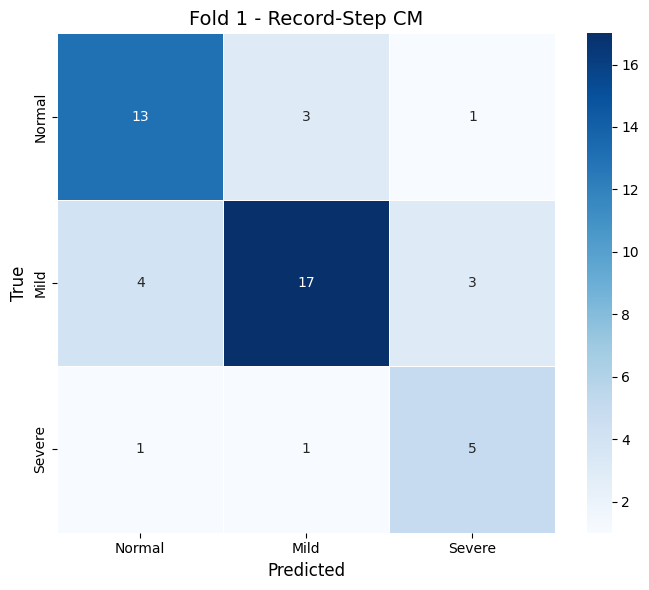


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3858 - loss: 1.5015  val_record_step_balanced_accuracy: 0.3560
78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.4211 - loss: 1.4555 - val_accuracy: 0.4487 - val_loss: 1.0220 - val_record_step_balanced_accuracy: 0.3560 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4672 - loss: 1.3271  val_record_step_balanced_accuracy: 0.5805
78/78 ━━

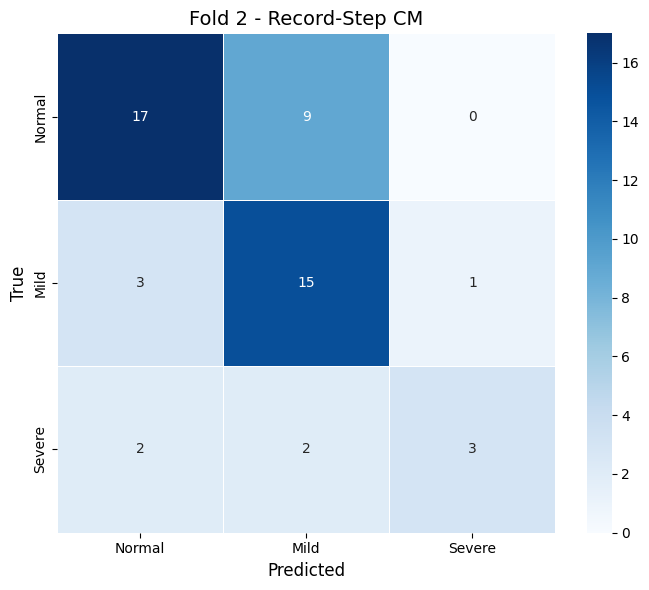


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3826 - loss: 1.5352  val_record_step_balanced_accuracy: 0.4850
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.4167 - loss: 1.4235 - val_accuracy: 0.4048 - val_loss: 1.0736 - val_record_step_balanced_accuracy: 0.4850 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4915 - loss: 1.3172  val_record_step_balanced_accuracy: 0.4674
80/80 ━━

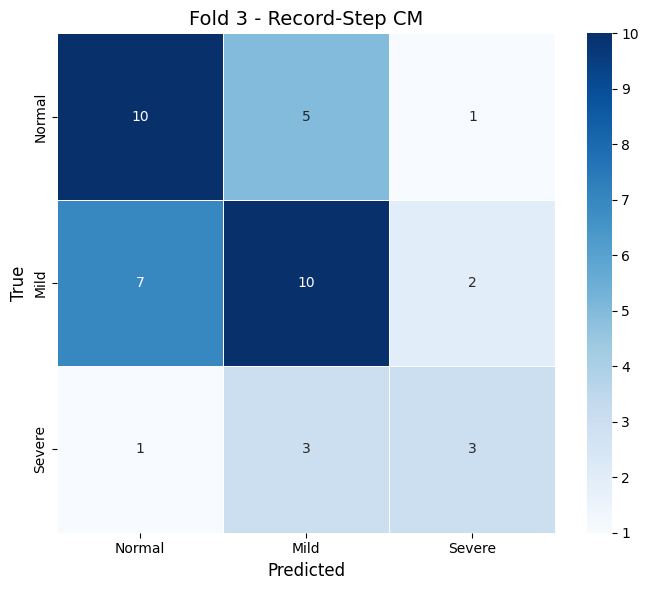


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 5)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3600 - loss: 1.4623  val_record_step_balanced_accuracy: 0.5265
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.4101 - loss: 1.4010 - val_accuracy: 0.5185 - val_loss: 1.0334 - val_record_step_balanced_accuracy: 0.5265 - learning_rate: 0.0010
Epoch 2/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4831 - loss: 1.2645  val_record_step_balanced_accuracy: 0.5009
79/79 ━━

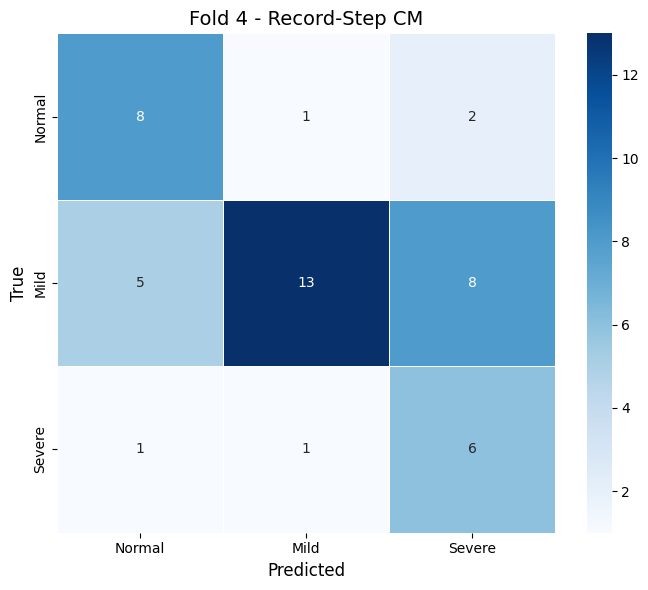


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3940 - loss: 1.5755  val_record_step_balanced_accuracy: 0.5103
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.4410 - loss: 1.4725 - val_accuracy: 0.5238 - val_loss: 0.9371 - val_record_step_balanced_accuracy: 0.5103 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4488 - loss: 1.4254  val_record_step_balanced_accuracy: 0.5470
80/80 ━━

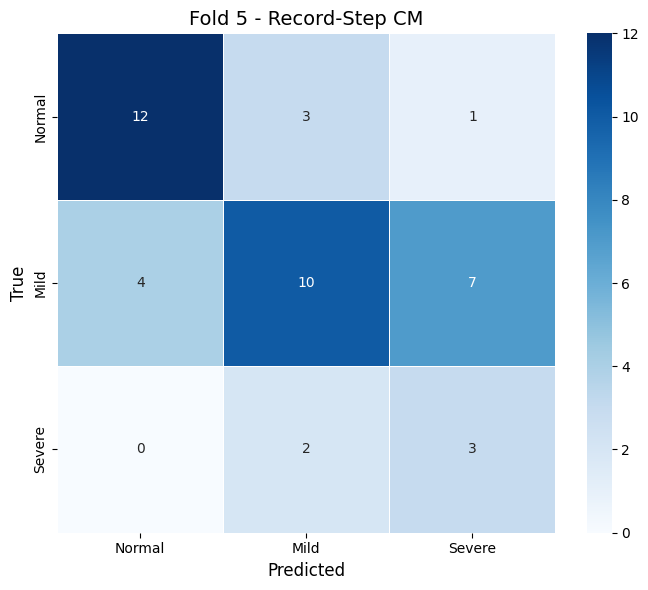


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3822 - loss: 1.5059  val_record_step_balanced_accuracy: 0.4222
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.4135 - loss: 1.4265 - val_accuracy: 0.4733 - val_loss: 1.0306 - val_record_step_balanced_accuracy: 0.4222 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5062 - loss: 1.3185  val_record_step_balanced_accuracy: 0.5694
78/78 ━━

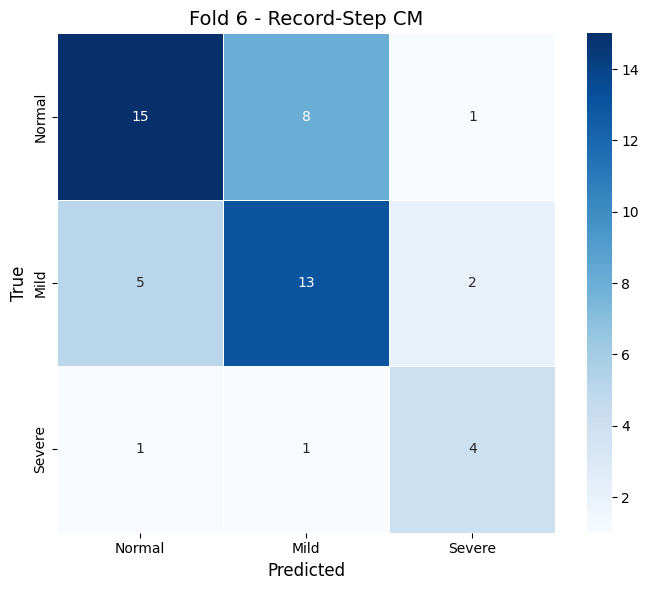


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4024 - loss: 1.5780  val_record_step_balanced_accuracy: 0.6239
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4325 - loss: 1.4865 - val_accuracy: 0.5435 - val_loss: 0.9741 - val_record_step_balanced_accuracy: 0.6239 - learning_rate: 0.0010
Epoch 2/100
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4920 - loss: 1.3795  val_record_step_balanced_accuracy: 0.6624
79/79 ━━━

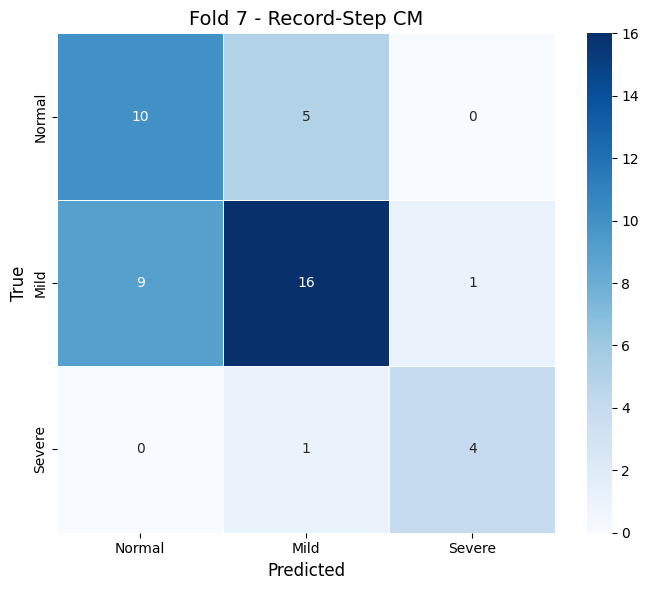


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 5)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4204 - loss: 1.4661  val_record_step_balanced_accuracy: 0.6130
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.4542 - loss: 1.4040 - val_accuracy: 0.5000 - val_loss: 0.9957 - val_record_step_balanced_accuracy: 0.6130 - learning_rate: 0.0010
Epoch 2/100
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5212 - loss: 1.3077  val_record_step_balanced_accuracy: 0.6282
80/80 ━━━

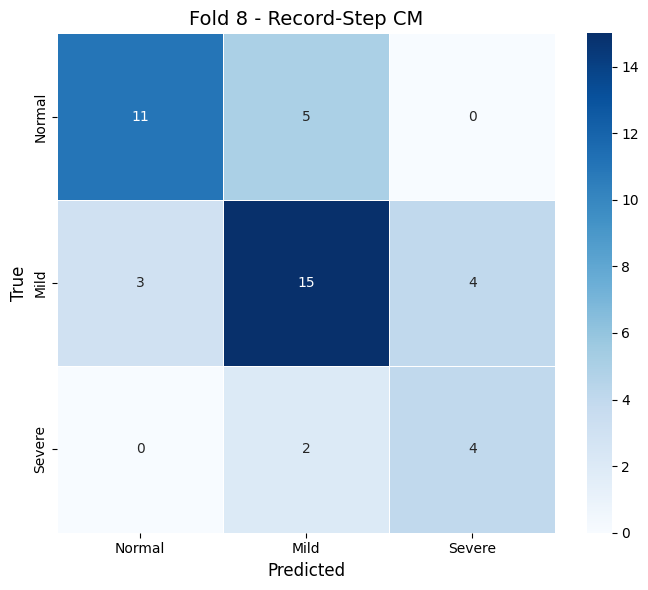


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 5)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3905 - loss: 1.5619  val_record_step_balanced_accuracy: 0.4507
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.4329 - loss: 1.4882 - val_accuracy: 0.4902 - val_loss: 1.0607 - val_record_step_balanced_accuracy: 0.4507 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4907 - loss: 1.3233  val_record_step_balanced_accuracy: 0.4275
78/78 ━

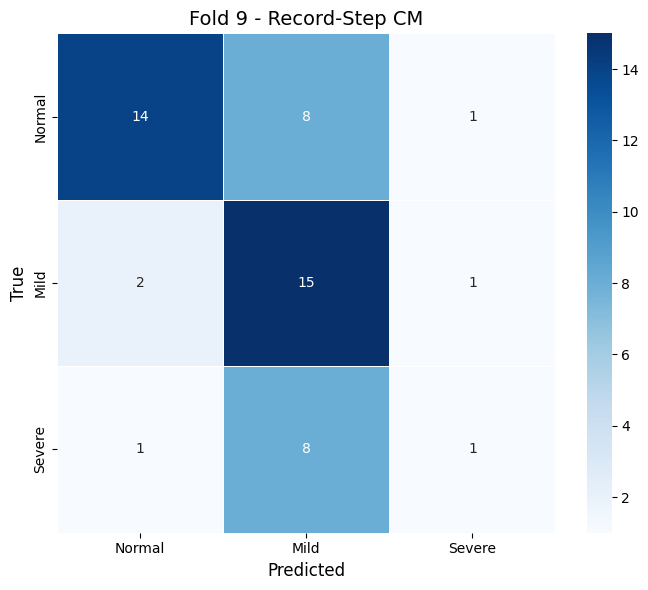


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 5)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4598 - loss: 1.4367  val_record_step_balanced_accuracy: 0.6008
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.4778 - loss: 1.4053 - val_accuracy: 0.5072 - val_loss: 0.9970 - val_record_step_balanced_accuracy: 0.6008 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4863 - loss: 1.3441  val_record_step_balanced_accuracy: 0.6596
79/79 ━━

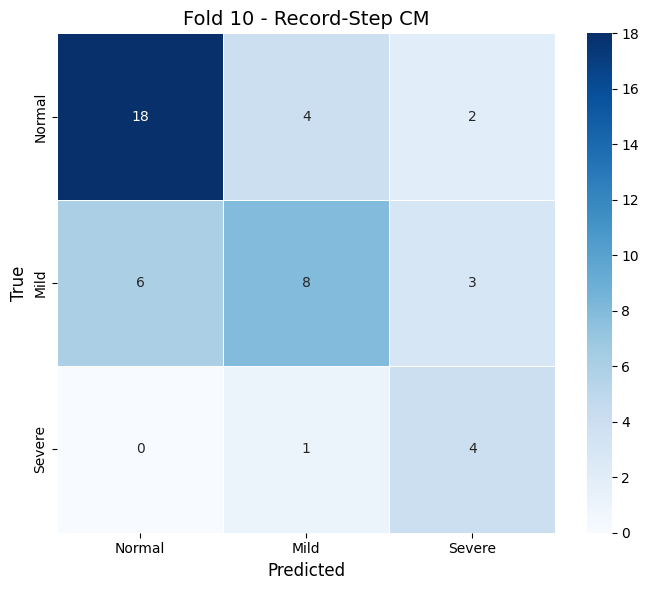


CROSS-VALIDATION SUMMARY (Record-Step) - Feature mode C
  Reliable folds: 10 / 10 (effective threshold: 5 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6360 +/- 0.0507
  balanced_accuracy     : 0.6355 +/- 0.0661
  macro_f1              : 0.6117 +/- 0.0658
  --------------------------------------------------
  precision_Normal  : 0.6972 +/- 0.1005
  recall_Normal  : 0.6859 +/- 0.0556
  f1_Normal  : 0.6868 +/- 0.0600
  precision_Mild    : 0.6575 +/- 0.1121
  recall_Mild    : 0.6251 +/- 0.1236
  f1_Mild    : 0.6266 +/- 0.0666
  precision_Severe  : 0.5102 +/- 0.1606
  recall_Severe  : 0.5955 +/- 0.2081
  f1_Severe  : 0.5219 +/- 0.1623

Overall Confusion Matrix (all folds combined):
[[128  51   9]
 [ 48 132  32]
 [  7  22  37]]

  All folds are reliable - no filtering needed.


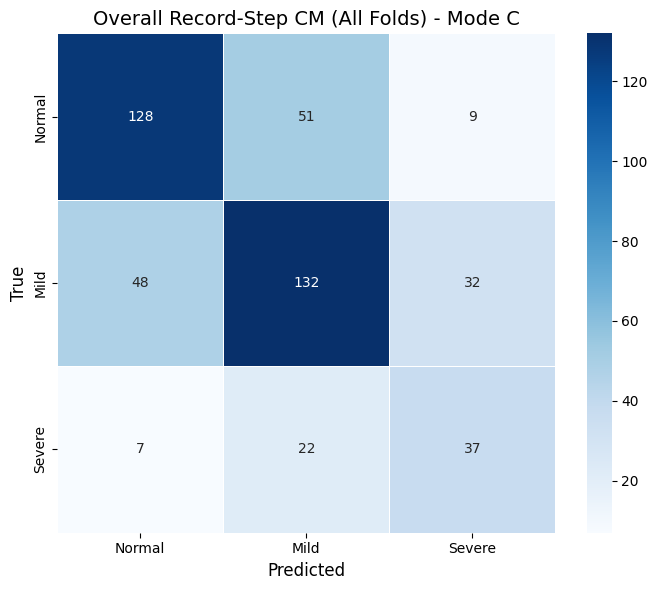

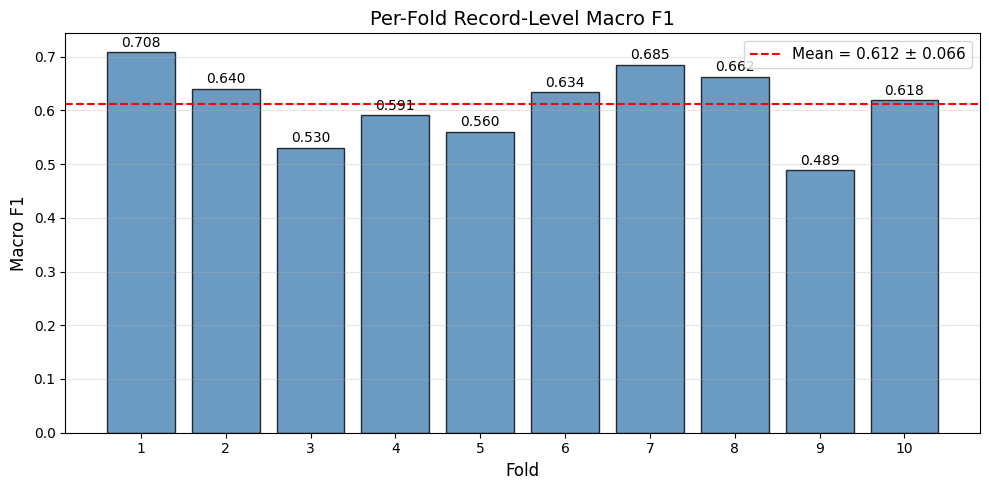

Manual weights: {0: 0.9, 1: 1.2, 2: 2.5}
Effective Severe threshold/fold: 5
Mean macro F1: 0.6117
Mean balanced accuracy: 0.6355
Mean Mild recall: 0.6251
Mean Severe recall: 0.5955

Run summary saved to outputs\step23_softmax_short_plan\step23_softmax_results.json


In [221]:
def _manual_class_weight_resolver_factory(manual_weights):
    def _resolver(y_train: np.ndarray) -> dict:
        if manual_weights is None:
            return _original_compute_class_weights_from_y(y_train)
        resolved = {
            int(class_idx): float(manual_weights.get(class_idx, 1.0))
            for class_idx in range(NUM_CLASSES)
        }
        print(f"  Class weights (manual override): {resolved}")
        return resolved
    return _resolver


try:
    print("\n" + "=" * 70)
    print("Running fixed class-weight experiment")
    print(f"Manual class weights: {manual_class_weights}")
    print("=" * 70)

    compute_class_weights_from_y = _manual_class_weight_resolver_factory(manual_class_weights)
    scratch_results = run_grouped_cv(
        X=X_all,
        y=y_all,
        groups=groups_all,
        metadata=meta_all,
        cfg=CFG,
        X_raw=X_all,
        feature_missing_frac=meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32),
    )
finally:
    compute_class_weights_from_y = _original_compute_class_weights_from_y

effective_min_severe_threshold = (
    scratch_results[0].get('effective_min_severe_threshold', CFG['min_severe_records'])
    if scratch_results else CFG['min_severe_records']
)

scratch_summary = {
    'experiment': 'fixed_class_weights',
    'steps': CFG['step_numbers'],
    'n_folds': CFG['n_splits'],
    'n_reliable_folds': len([result for result in scratch_results if result.get('is_reliable', True)]),
    'window_length': CFG['segment_length'],
    'max_nan_fraction': CFG['max_nan_fraction'],
    'n_windows': len(X_all),
    'n_records': int(len(np.unique(groups_all))),
    'n_record_steps': int(len(step_unit_table)),
    'manual_class_weights': manual_class_weights,
    'requested_min_severe_threshold': CFG['min_severe_records'],
    'effective_min_severe_threshold': effective_min_severe_threshold,
    'mean_macro_f1': float(np.mean([result['macro_f1'] for result in scratch_results])),
    'std_macro_f1': float(np.std([result['macro_f1'] for result in scratch_results])),
    'mean_balanced_acc': float(np.mean([result['balanced_accuracy'] for result in scratch_results])),
    'std_balanced_acc': float(np.std([result['balanced_accuracy'] for result in scratch_results])),
    'mean_accuracy': float(np.mean([result['accuracy'] for result in scratch_results])),
    'std_accuracy': float(np.std([result['accuracy'] for result in scratch_results])),
    'mean_recall_Normal': float(np.mean([result['recall_Normal'] for result in scratch_results])),
    'mean_recall_Mild': float(np.mean([result['recall_Mild'] for result in scratch_results])),
    'mean_recall_Severe': float(np.mean([result['recall_Severe'] for result in scratch_results])),
    'per_fold': [
        {key: value for key, value in result.items() if key != 'confusion_matrix'}
        for result in scratch_results
    ],
}

reliable_results = [result for result in scratch_results if result.get('is_reliable', True)]
if reliable_results:
    scratch_summary['reliable_mean_macro_f1'] = float(np.mean([result['macro_f1'] for result in reliable_results]))
    scratch_summary['reliable_std_macro_f1'] = float(np.std([result['macro_f1'] for result in reliable_results]))
    scratch_summary['reliable_mean_balanced_acc'] = float(np.mean([result['balanced_accuracy'] for result in reliable_results]))
    scratch_summary['reliable_std_balanced_acc'] = float(np.std([result['balanced_accuracy'] for result in reliable_results]))

with open(OUTPUT_DIR / "step23_softmax_results.json", 'w') as summary_file:
    json.dump(scratch_summary, summary_file, indent=2, default=str)

print(f"Manual weights: {manual_class_weights}")
print(f"Effective Severe threshold/fold: {effective_min_severe_threshold}")
print(f"Mean macro F1: {scratch_summary['mean_macro_f1']:.4f}")
print(f"Mean balanced accuracy: {scratch_summary['mean_balanced_acc']:.4f}")
print(f"Mean Mild recall: {scratch_summary['mean_recall_Mild']:.4f}")
print(f"Mean Severe recall: {scratch_summary['mean_recall_Severe']:.4f}")
print(f"\nRun summary saved to {OUTPUT_DIR / 'step23_softmax_results.json'}")

In [222]:
#Final summary
def _fmt(values):
    return f"{np.mean(values):.4f} +/- {np.std(values):.4f}"
print("Final Summary")

if 'scratch_results' not in globals() or 'scratch_summary' not in globals():
    raise RuntimeError("Run the experiment cell first to execute the fixed class-weight experiment.")

requested_threshold = scratch_summary.get('requested_min_severe_threshold', CFG['min_severe_records'])
effective_threshold = scratch_summary.get('effective_min_severe_threshold', requested_threshold)

print(f"\nExperiment: {scratch_summary['experiment']}")
print(f"Manual weights: {scratch_summary.get('manual_class_weights')}")

print(f"\nExperiment scope:")
print(f"Steps used: {CFG['step_numbers']}")
print(f"Window length: {CFG['segment_length']} samples ({CFG['segment_minutes']} min)")
print(f"Max NaN fraction: {CFG['max_nan_fraction']:.0%}")
print(f"Grouped CV by rec_id: yes")
print(f"Evaluation unit: record-step")
print(f"Feature branch: compact engineered FHR features")
print(f"Requested Severe threshold:{requested_threshold}")
print(f"Effective Severe threshold:{effective_threshold}")

print(f"\nPer-fold reliability (effective min Severe step-units = {effective_threshold}):")
print(f"  {'Fold':<8} {'Macro F1':>12} {'Reliable?':>12}  {'Severe step-units':>18}")

for index in range(CFG['n_splits']):
    fold = scratch_results[index]
    reliable_label = "Yes" if fold.get('is_reliable', True) else "No"
    severe_count = fold.get('n_severe_val_step_units', '?')
    print(f"  Fold {index + 1:<3} {fold['macro_f1']:>12.4f} {reliable_label:>12}  {severe_count:>18}")

print(f"\nRecord-step metrics across all folds:")
for metric_name in ['accuracy', 'balanced_accuracy', 'macro_f1']:
    metric_values = [fold[metric_name] for fold in scratch_results]
    print(f"  {metric_name:<22} {_fmt(metric_values)}")

print("\nPer-class recall:")
for class_name in CLASS_NAMES:
    metric_values = [fold[f'recall_{class_name}'] for fold in scratch_results]
    print(f"  {class_name:<22} {_fmt(metric_values)}")

print("\nPer-class F1:")
for class_name in CLASS_NAMES:
    metric_values = [fold[f'f1_{class_name}'] for fold in scratch_results]
    print(f"  {class_name:<22} {_fmt(metric_values)}")

reliable_folds = [fold for fold in scratch_results if fold.get('is_reliable', True)]
if 0 < len(reliable_folds) < CFG['n_splits']:
    print(f"\nReliable folds only ({len(reliable_folds)}/{CFG['n_splits']}):")
    for metric_name in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        metric_values = [fold[metric_name] for fold in reliable_folds]
        print(f"  {metric_name:<22} {_fmt(metric_values)}")
elif len(reliable_folds) == CFG['n_splits']:
    print("\nAll folds met the validation reliability threshold.")

print("Results saved to", OUTPUT_DIR)

Final Summary

Experiment: fixed_class_weights
Manual weights: {0: 0.9, 1: 1.2, 2: 2.5}

Experiment scope:
Steps used: [2, 3]
Window length: 1800 samples (30 min)
Max NaN fraction: 16%
Grouped CV by rec_id: yes
Evaluation unit: record-step
Feature branch: compact engineered FHR features
Requested Severe threshold:10
Effective Severe threshold:5

Per-fold reliability (effective min Severe step-units = 5):
  Fold         Macro F1    Reliable?   Severe step-units
  Fold 1         0.7078          Yes                   7
  Fold 2         0.6402          Yes                   7
  Fold 3         0.5301          Yes                   7
  Fold 4         0.5914          Yes                   8
  Fold 5         0.5602          Yes                   5
  Fold 6         0.6337          Yes                   6
  Fold 7         0.6850          Yes                   5
  Fold 8         0.6622          Yes                   6
  Fold 9         0.4887          Yes                  10
  Fold 10        0.618